In [1]:
covert_path_raw = "/Users/kalyanbrata/Documents/MATLAB/FeatureAttention/logs/eeg_20260909_152805/eeg_20260909_152805_raw.csv"
covert_path_health = "/Users/kalyanbrata/Documents/MATLAB/FeatureAttention/logs/eeg_20260909_152805/eeg_20260909_152805_health.csv"
overt_path_raw = "/Users/kalyanbrata/Documents/MATLAB/FeatureAttention/logs/eeg_20260909_172031/eeg_20260909_172031_raw.csv"
overt_path_health = "/Users/kalyanbrata/Documents/MATLAB/FeatureAttention/logs/eeg_20260909_172031/eeg_20260909_172031_health.csv"

path_raw = overt_path_raw
path_health = overt_path_health

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.fft import rfft, rfftfreq
from scipy.linalg import svd
from scipy.stats import mannwhitneyu
import time

# --- Known montage: only channels 9-16 are confirmed real EEG (occipital/parietal/central) ---
MONTAGE = {9:'CZ', 10:'PZ', 11:'P4', 12:'T6', 13:'T5', 14:'P3', 15:'O2', 16:'O1', 17:'GND', 18:'REF'}
EEG_CHANNELS = [9, 10, 11, 12, 13, 14, 15, 16]
eeg_cols = [f'raw{ch}' for ch in EEG_CHANNELS]
eeg_labels = [MONTAGE[ch] for ch in EEG_CHANNELS]

def make_bandpass(low=4, high=45, fs=251.7, order=4):
    nyq = fs / 2
    return butter(order, [low/nyq, high/nyq], btype='band')

def make_notch(freq=50, fs=251.7, Q=30):
    return iirnotch(freq/(fs/2), Q)

def load_session(raw_path, health_path, target_freq):
    """
    Loads one recording session, filters it, and extracts trial-aligned
    stim/rest windows using the marker semantics:
      20 = trial start, 30 = trial stop, 40 = response, 0 = reset

    Pairing is done by finding the NEXT valid marker-30 after each marker-20
    (rather than pairing by index position), since sessions can contain
    stray/incomplete markers (e.g. a leftover 30 before the first real 20).
    """
    df = pd.read_csv(raw_path)
    health = pd.read_csv(health_path)
    board_ms_span = health['board_ms'].iloc[-1] - health['board_ms'].iloc[0]
    fs = len(df) / (board_ms_span / 1000)

    b_bp, a_bp = make_bandpass(fs=fs)
    b_notch, a_notch = make_notch(fs=fs)

    raw_matrix = df[eeg_cols].values.astype(float)
    filtered = filtfilt(b_notch, a_notch, raw_matrix, axis=0)
    filtered = filtfilt(b_bp, a_bp, filtered, axis=0)

    marker_series = df['marker'].values
    transitions = np.where(np.diff(marker_series) != 0)[0] + 1
    transition_values = marker_series[transitions]

    onsets_20 = transitions[(transition_values == 20) | (transition_values == 21)]
    onsets_30 = transitions[transition_values == 30]
    onsets_40 = transitions[transition_values == 40]

    # --- Robust pairing: for each 20, find the first 30 that comes AFTER it ---
    stim_windows = []
    valid_20 = []
    for start in onsets_20:
        later_30 = onsets_30[onsets_30 > start]
        if len(later_30) == 0:
            continue
        end = later_30[0]
        stim_windows.append(filtered[start:end, :])
        valid_20.append(start)
    valid_20 = np.array(valid_20)
    n_trials = len(stim_windows)

    # --- Rest windows: marker40 -> next marker20 (same robust "next after" logic) ---
    rest_windows = []
    for start in onsets_40:
        later_20 = onsets_20[onsets_20 > start]
        if len(later_20) == 0:
            continue
        end = later_20[0]
        rest_windows.append(filtered[start:end, :])

    return {
        'target_freq': target_freq,
        'fs': fs,
        'filtered': filtered,
        'n_trials': n_trials,
        'onsets_20': valid_20, 'onsets_30': onsets_30, 'onsets_40': onsets_40,
        'stim_windows': stim_windows,
        'rest_windows': rest_windows,
    }

# --- Load both sessions with the corrected pairing logic ---
sessions = {
    '20Hz': load_session(
        path_raw,
        path_health,
        target_freq=20),
    '16Hz': load_session(
        path_raw,
        path_health,
        target_freq=16),
}

for name, s in sessions.items():
    stim_lens = [w.shape[0] for w in s['stim_windows']]
    print(f"{name}: fs={s['fs']:.2f}, trials={s['n_trials']}, "
          f"stim_lens=[{min(stim_lens)}-{max(stim_lens)}], "
          f"rest_windows={len(s['rest_windows'])}")

20Hz: fs=249.70, trials=42, stim_lens=[2491-3271], rest_windows=39
16Hz: fs=249.70, trials=42, stim_lens=[2491-3271], rest_windows=39


In [3]:
def psda_score(x, fs, target_freq, n_harmonics=1, signal_halfwidth=0.5, noise_band=2.0, guard=1.0):
    """
    x: 1D array, single channel, single window
    Local-SNR score at target_freq (and optionally its harmonics, averaged).
    """
    n = len(x)
    x = x - x.mean()
    spec = np.abs(rfft(x)) ** 2
    freqs = rfftfreq(n, d=1/fs)

    snrs = []
    for h in range(1, n_harmonics + 1):
        f0 = target_freq * h
        sig_mask = (freqs >= f0 - signal_halfwidth) & (freqs <= f0 + signal_halfwidth)
        noise_mask = (freqs >= f0 - noise_band) & (freqs <= f0 + noise_band) & \
                     ~((freqs >= f0 - guard) & (freqs <= f0 + guard))
        if sig_mask.sum() == 0 or noise_mask.sum() == 0:
            continue
        signal = spec[sig_mask].max()
        noise = spec[noise_mask].mean()
        if noise == 0:
            continue
        snrs.append(signal / noise)

    return np.mean(snrs) if snrs else np.nan

def multichannel_psda_score(X, fs, target_freq, n_harmonics=1):
    """
    X: (n_samples, n_channels) window
    Returns the MEAN psda_score across all channels in X (per-channel method,
    combined only by simple averaging at the end -- not a spatial filter like CCA).
    """
    scores = [psda_score(X[:, c], fs, target_freq, n_harmonics) for c in range(X.shape[1])]
    scores = [s for s in scores if not np.isnan(s)]
    return np.mean(scores) if scores else np.nan

# --- Channel-set definitions, reused across the whole sweep ---
CHANNEL_SETS = {
    'occipital_only': ['O1', 'O2'],
    'parietal_only': ['PZ', 'P3', 'T5'],
    'all_8': eeg_labels,   # CZ, PZ, P4, T6, T5, P3, O2, O1
}

def get_channel_indices(channel_set_name):
    names = CHANNEL_SETS[channel_set_name]
    return [eeg_labels.index(n) for n in names]

# --- Quick sanity test on a single window, before running the full sweep ---
test_session = sessions['20Hz']
test_window = test_session['stim_windows'][0][:int(test_session['fs']*2), :]  # first 2s of trial 0
ch_idx = get_channel_indices('occipital_only')
test_score = multichannel_psda_score(test_window[:, ch_idx], test_session['fs'], target_freq=20, n_harmonics=1)
print(f"Sanity check - occipital PSDA score, trial 0, 2s window, 20Hz target: {test_score:.3f}")

Sanity check - occipital PSDA score, trial 0, 2s window, 20Hz target: 0.758


In [4]:
def run_psda_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    """
    Runs PSDA scoring across a session's trials for one configuration,
    sliding a window through each stim/rest trial, and returns summary metrics.

    test_freq: the frequency we SCORE against (may differ from the session's
               actual stimulation frequency -- this lets us test cross-frequency,
               e.g. does the 20Hz session score high when tested against 16Hz).
    """
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    def score_trial_windows(trial_data):
        """Slide a window through one trial, return list of per-window scores + compute times."""
        scores, comp_times = [], []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start = w * hop_len
            end = start + window_len
            X = trial_data[start:end, ch_idx]
            t0 = time.perf_counter()
            sc = multichannel_psda_score(X, fs, test_freq, n_harmonics)
            comp_times.append(time.perf_counter() - t0)
            scores.append(sc)
        return scores, comp_times

    all_stim_scores, all_rest_scores, all_comp_times = [], [], []
    per_trial_stim_scores = []   # list of lists, one per trial (for accuracy calc)
    per_trial_rest_scores = []

    for trial in s['stim_windows']:
        sc, ct = score_trial_windows(trial)
        per_trial_stim_scores.append(sc)
        all_stim_scores.extend(sc)
        all_comp_times.extend(ct)

    for trial in s['rest_windows']:
        sc, ct = score_trial_windows(trial)
        per_trial_rest_scores.append(sc)
        all_rest_scores.extend(sc)
        all_comp_times.extend(ct)

    all_stim_scores = np.array([x for x in all_stim_scores if not np.isnan(x)])
    all_rest_scores = np.array([x for x in all_rest_scores if not np.isnan(x)])

    if len(all_stim_scores) < 2 or len(all_rest_scores) < 2:
        return None  # window too long for this trial length, skip

    # --- Stats: separation + effect size ---
    mean_stim, mean_rest = all_stim_scores.mean(), all_rest_scores.mean()
    pooled_std = np.sqrt((all_stim_scores.std()**2 + all_rest_scores.std()**2) / 2)
    cohens_d = (mean_stim - mean_rest) / pooled_std if pooled_std > 0 else np.nan
    try:
        _, pval = mannwhitneyu(all_stim_scores, all_rest_scores, alternative='greater')
    except ValueError:
        pval = np.nan

    # --- Per-trial accuracy: threshold = midpoint between stim/rest medians ---
    threshold = (np.median(all_stim_scores) + np.median(all_rest_scores)) / 2
    stim_correct = sum(np.nanmean(np.array(t) > threshold) > 0.5 for t in per_trial_stim_scores if len(t) > 0)
    rest_correct = sum(np.nanmean(np.array(t) <= threshold) > 0.5 for t in per_trial_rest_scores if len(t) > 0)
    n_stim_trials = sum(1 for t in per_trial_stim_scores if len(t) > 0)
    n_rest_trials = sum(1 for t in per_trial_rest_scores if len(t) > 0)
    accuracy = (stim_correct + rest_correct) / (n_stim_trials + n_rest_trials) if (n_stim_trials + n_rest_trials) > 0 else np.nan
    false_positive_rate = 1 - (rest_correct / n_rest_trials) if n_rest_trials > 0 else np.nan

    avg_compute_time = np.mean(all_comp_times)
    latency_sec = window_sec + avg_compute_time  # window collection time + processing time

    return {
        'session': session_name, 'actual_freq': s['target_freq'], 'test_freq': test_freq,
        'window_sec': window_sec, 'channel_set': channel_set_name, 'n_harmonics': n_harmonics,
        'n_stim_windows': len(all_stim_scores), 'n_rest_windows': len(all_rest_scores),
        'mean_stim': mean_stim, 'mean_rest': mean_rest, 'cohens_d': cohens_d, 'pval': pval,
        'accuracy': accuracy, 'false_positive_rate': false_positive_rate,
        'avg_compute_ms': avg_compute_time * 1000, 'latency_sec': latency_sec,
    }

# --- Sanity test: run ONE config end-to-end before looping over all 72 ---
result = run_psda_config('20Hz', window_sec=2.0, channel_set_name='occipital_only', n_harmonics=1, test_freq=20)
print(result)

{'session': '20Hz', 'actual_freq': 20, 'test_freq': 20, 'window_sec': 2.0, 'channel_set': 'occipital_only', 'n_harmonics': 1, 'n_stim_windows': 3529, 'n_rest_windows': 188, 'mean_stim': np.float64(3.6456131041498163), 'mean_rest': np.float64(3.009675296437196), 'cohens_d': np.float64(0.20663796621323152), 'pval': np.float64(0.021261058965357935), 'accuracy': np.float64(0.5061728395061729), 'false_positive_rate': np.float64(0.46153846153846156), 'avg_compute_ms': np.float64(0.07370084904751648), 'latency_sec': np.float64(2.0000737008490477)}


In [5]:
# --- Define the full parameter grid ---
window_lengths = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
channel_set_names = list(CHANNEL_SETS.keys())   # occipital_only, parietal_only, all_8
harmonics_options = [1, 2]
session_names = list(sessions.keys())            # 20Hz, 16Hz

# --- Test frequencies: for each session, test against its OWN actual frequency AND the other one ---
# This directly tests H4 (does detection track the real stimulus, not just "any nearby frequency")
test_freq_map = {
    '20Hz': [20, 16],   # session actually stimulated at 20Hz -> test against both
    '16Hz': [16, 20],
}

results = []
total_configs = sum(len(window_lengths) * len(channel_set_names) * len(harmonics_options) * len(test_freq_map[sn])
                     for sn in session_names)
print(f"Running {total_configs} configurations...")

count = 0
for session_name in session_names:
    for test_freq in test_freq_map[session_name]:
        for window_sec in window_lengths:
            for channel_set_name in channel_set_names:
                for n_harmonics in harmonics_options:
                    count += 1
                    r = run_psda_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq)
                    if r is not None:
                        results.append(r)
                    if count % 20 == 0:
                        print(f"  ...{count}/{total_configs} done")

results_df = pd.DataFrame(results)
print(f"\nCompleted. {len(results_df)} valid configurations out of {total_configs} attempted.")
results_df.head(10)

Running 144 configurations...
  ...20/144 done
  ...40/144 done
  ...60/144 done
  ...80/144 done
  ...100/144 done
  ...120/144 done
  ...140/144 done

Completed. 96 valid configurations out of 144 attempted.


,session,actual_freq,test_freq,window_sec,channel_set,n_harmonics,n_stim_windows,n_rest_windows,mean_stim,mean_rest,cohens_d,pval,accuracy,false_positive_rate,avg_compute_ms,latency_sec
0,20Hz,20,20,0.5,occipital_only,1,4163,801,8.901993,4.888470,0.086057,0.003767,0.604938,0.435897,0.051469,0.500051
1,20Hz,20,20,0.5,occipital_only,2,4163,801,9.235217,5.431514,0.051230,0.004605,0.580247,0.435897,0.071534,0.500072
2,20Hz,20,20,0.5,parietal_only,1,4163,801,17.671019,8.486819,0.035831,0.131152,0.530864,0.512821,0.074123,0.500074
3,20Hz,20,20,0.5,parietal_only,2,4163,801,12.323418,7.721204,0.035319,0.130517,0.543210,0.461538,0.111485,0.500111
4,20Hz,20,20,0.5,all_8,1,4163,801,12.977687,6.456292,0.063075,0.000254,0.629630,0.384615,0.194095,0.500194
5,20Hz,20,20,0.5,all_8,2,4163,801,10.918327,6.246586,0.077166,0.003886,0.617284,0.358974,0.280360,0.500280
6,20Hz,20,20,1.0,occipital_only,1,3950,600,2.521876,2.144833,0.080643,0.009477,0.481481,0.564103,0.059745,1.000060
7,20Hz,20,20,1.0,occipital_only,2,3950,600,2.197116,1.983113,0.067990,0.189784,0.481481,0.564103,0.080828,1.000081
8,20Hz,20,20,1.0,parietal_only,1,3950,600,2.266580,2.041675,0.068604,0.453618,0.530864,0.487179,0.085874,1.000086
9,20Hz,20,20,1.0,parietal_only,2,3950,600,2.057495,1.924772,0.065484,0.062222,0.567901,0.461538,0.117625,1.000118


Matched configs: 48, Mismatched (H4 check) configs: 48

=== Top 10 configs by effect size (matched frequency) ===
session  window_sec    channel_set  n_harmonics  cohens_d         pval  accuracy  latency_sec
   16Hz         2.0          all_8            1  0.787162 1.096747e-23  0.641975     2.000306
   16Hz         2.0          all_8            2  0.762631 4.810998e-20  0.654321     2.000369
   16Hz         1.5          all_8            1  0.541775 5.493860e-24  0.580247     1.500209
   16Hz         1.5          all_8            2  0.510707 1.778189e-19  0.604938     1.500303
   20Hz         2.0          all_8            1  0.450953 1.796827e-06  0.543210     2.000295
   20Hz         2.0          all_8            2  0.429243 1.916489e-05  0.530864     2.000379
   16Hz         2.0 occipital_only            1  0.421937 8.487756e-08  0.604938     2.000075
   20Hz         1.5          all_8            1  0.376276 5.069578e-15  0.592593     1.500208
   16Hz         1.0          all_8      

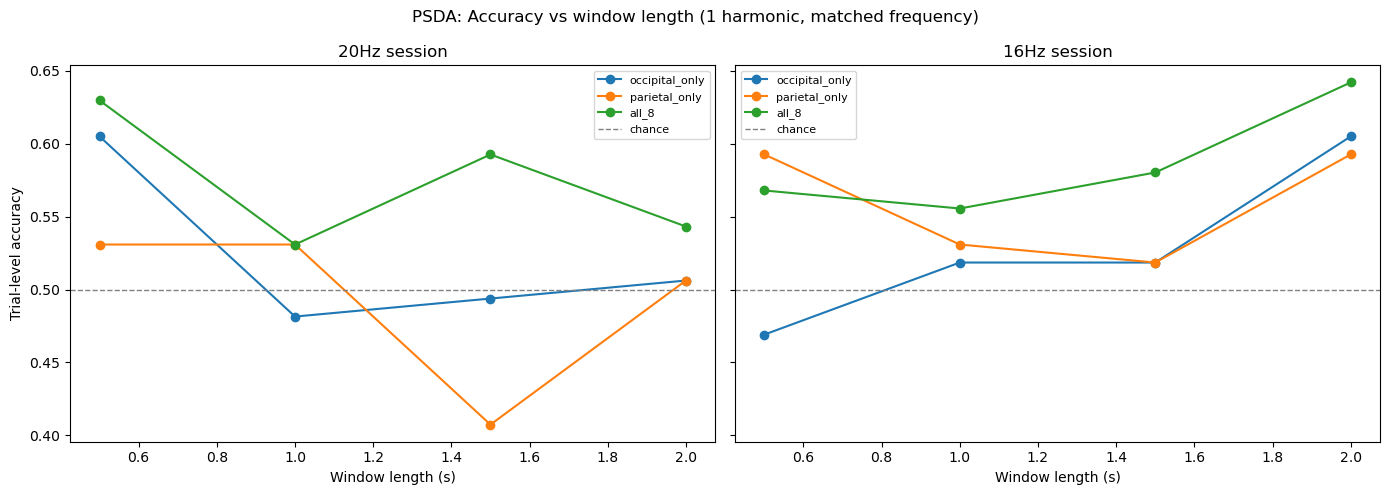

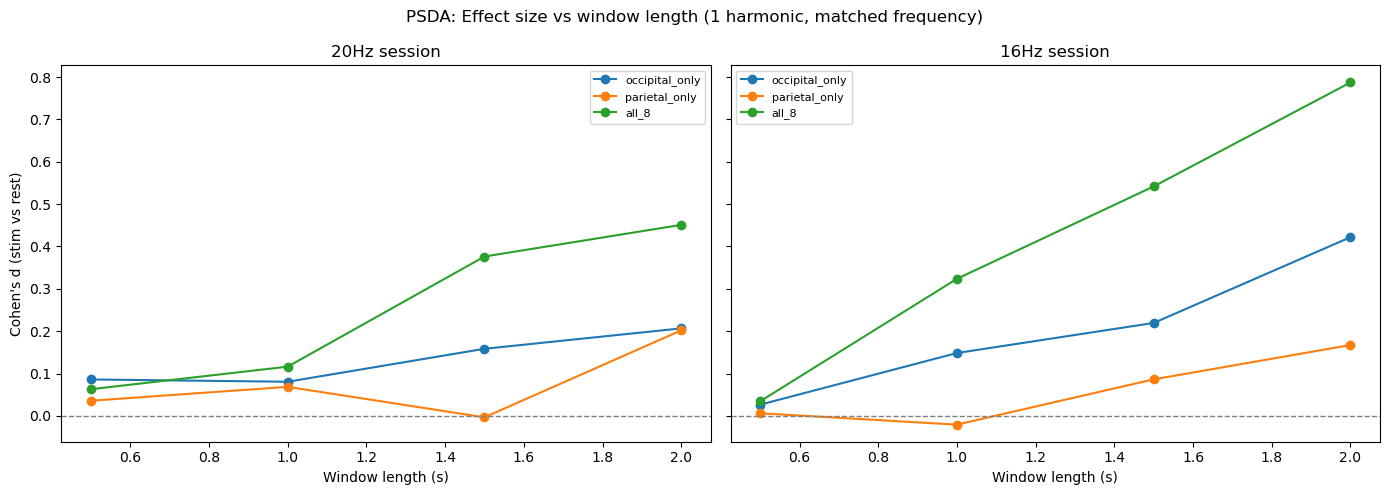

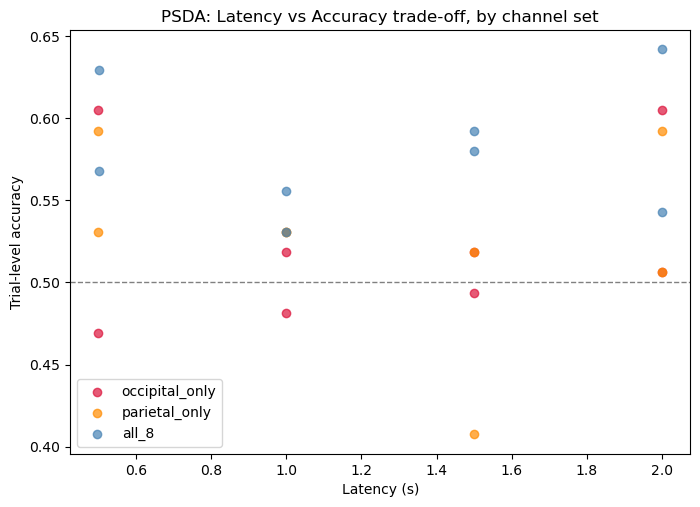

In [6]:
# --- Split into "matched" (testing at the session's real frequency) vs "mismatched" (H4 check) ---
matched = results_df[results_df['actual_freq'] == results_df['test_freq']].copy()
mismatched = results_df[results_df['actual_freq'] != results_df['test_freq']].copy()

print(f"Matched configs: {len(matched)}, Mismatched (H4 check) configs: {len(mismatched)}")

# --- Top 10 configs by Cohen's d, matched only ---
print("\n=== Top 10 configs by effect size (matched frequency) ===")
top10 = matched.sort_values('cohens_d', ascending=False).head(10)
print(top10[['session', 'window_sec', 'channel_set', 'n_harmonics', 'cohens_d', 'pval', 'accuracy', 'latency_sec']].to_string(index=False))

# --- Plot 1: Accuracy vs window length, one line per channel set, faceted by session ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, session_name in zip(axes, session_names):
    sub = matched[(matched['session'] == session_name) & (matched['n_harmonics'] == 1)]
    for cs in channel_set_names:
        cs_data = sub[sub['channel_set'] == cs].sort_values('window_sec')
        ax.plot(cs_data['window_sec'], cs_data['accuracy'], marker='o', label=cs)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
    ax.set_title(f'{session_name} session')
    ax.set_xlabel('Window length (s)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Trial-level accuracy')
fig.suptitle('PSDA: Accuracy vs window length (1 harmonic, matched frequency)')
plt.tight_layout()
plt.show()

# --- Plot 2: Cohen's d vs window length, same structure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, session_name in zip(axes, session_names):
    sub = matched[(matched['session'] == session_name) & (matched['n_harmonics'] == 1)]
    for cs in channel_set_names:
        cs_data = sub[sub['channel_set'] == cs].sort_values('window_sec')
        ax.plot(cs_data['window_sec'], cs_data['cohens_d'], marker='o', label=cs)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{session_name} session')
    ax.set_xlabel('Window length (s)')
    ax.legend(fontsize=8)
axes[0].set_ylabel("Cohen's d (stim vs rest)")
fig.suptitle('PSDA: Effect size vs window length (1 harmonic, matched frequency)')
plt.tight_layout()
plt.show()

# --- Plot 3: Latency vs Accuracy scatter, colored by channel set ---
plt.figure(figsize=(8, 5.5))
colors = {'occipital_only': 'crimson', 'parietal_only': 'darkorange', 'all_8': 'steelblue'}
for cs in channel_set_names:
    sub = matched[(matched['channel_set'] == cs) & (matched['n_harmonics'] == 1)]
    plt.scatter(sub['latency_sec'], sub['accuracy'], label=cs, color=colors[cs], alpha=0.7)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Latency (s)')
plt.ylabel('Trial-level accuracy')
plt.title('PSDA: Latency vs Accuracy trade-off, by channel set')
plt.legend()
plt.show()

In [7]:
# --- Add each individual channel as its own "channel set", alongside the existing groups ---
CHANNEL_SETS_FULL = dict(CHANNEL_SETS)  # keep occipital_only, parietal_only, all_8
for label in eeg_labels:
    CHANNEL_SETS_FULL[f'ch_{label}'] = [label]

def get_channel_indices_full(channel_set_name):
    names = CHANNEL_SETS_FULL[channel_set_name]
    return [eeg_labels.index(n) for n in names]

# --- Re-point run_psda_config at the full channel-set dict ---
def run_psda_config_full(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    def score_trial_windows(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start = w * hop_len
            end = start + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(multichannel_psda_score(X, fs, test_freq, n_harmonics))
        return scores

    all_stim, all_rest = [], []
    per_trial_stim, per_trial_rest = [], []
    for trial in s['stim_windows']:
        sc = score_trial_windows(trial)
        per_trial_stim.append(sc)
        all_stim.extend(sc)
    for trial in s['rest_windows']:
        sc = score_trial_windows(trial)
        per_trial_rest.append(sc)
        all_rest.extend(sc)

    all_stim = np.array([x for x in all_stim if not np.isnan(x)])
    all_rest = np.array([x for x in all_rest if not np.isnan(x)])
    if len(all_stim) < 2 or len(all_rest) < 2:
        return None

    mean_stim, mean_rest = all_stim.mean(), all_rest.mean()
    pooled_std = np.sqrt((all_stim.std()**2 + all_rest.std()**2) / 2)
    cohens_d = (mean_stim - mean_rest) / pooled_std if pooled_std > 0 else np.nan
    try:
        _, pval = mannwhitneyu(all_stim, all_rest, alternative='greater')
    except ValueError:
        pval = np.nan

    threshold = (np.median(all_stim) + np.median(all_rest)) / 2
    stim_correct = sum(np.nanmean(np.array(t) > threshold) > 0.5 for t in per_trial_stim if len(t) > 0)
    rest_correct = sum(np.nanmean(np.array(t) <= threshold) > 0.5 for t in per_trial_rest if len(t) > 0)
    n_stim_t = sum(1 for t in per_trial_stim if len(t) > 0)
    n_rest_t = sum(1 for t in per_trial_rest if len(t) > 0)
    accuracy = (stim_correct + rest_correct) / (n_stim_t + n_rest_t) if (n_stim_t + n_rest_t) > 0 else np.nan

    return {
        'session': session_name, 'actual_freq': s['target_freq'], 'test_freq': test_freq,
        'window_sec': window_sec, 'channel_set': channel_set_name, 'n_harmonics': n_harmonics,
        'mean_stim': mean_stim, 'mean_rest': mean_rest, 'cohens_d': cohens_d, 'pval': pval,
        'accuracy': accuracy,
    }

# --- Run: all 8 individual channels + 3 groups, matched frequency only, 1 harmonic (our cleanest baseline) ---
baseline_results = []
all_channel_set_names = [f'ch_{l}' for l in eeg_labels] + list(CHANNEL_SETS.keys())

for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']  # matched only, for this baseline
    for window_sec in window_lengths:
        for cs_name in all_channel_set_names:
            r = run_psda_config_full(session_name, window_sec, cs_name, n_harmonics=1, test_freq=test_freq)
            if r is not None:
                baseline_results.append(r)

psda_baseline_df = pd.DataFrame(baseline_results)
print(f"PSDA baseline complete: {len(psda_baseline_df)} rows "
      f"({len(session_names)} sessions x {len(window_lengths)} windows x {len(all_channel_set_names)} channel sets)")
psda_baseline_df.to_csv('psda_baseline.csv', index=False)  # save so later CCA/TRCA cells can load and compare against this
psda_baseline_df.head()

PSDA baseline complete: 88 rows (2 sessions x 6 windows x 11 channel sets)


,session,actual_freq,test_freq,window_sec,channel_set,n_harmonics,mean_stim,mean_rest,cohens_d,pval,accuracy
0,20Hz,20,20,0.5,ch_CZ,1,11.295042,5.888768,0.054248,1.324015e-02,0.555556
1,20Hz,20,20,0.5,ch_PZ,1,19.645843,7.035938,0.019861,8.963477e-01,0.469136
2,20Hz,20,20,0.5,ch_P4,1,8.292367,6.013994,0.037936,2.211341e-06,0.530864
3,20Hz,20,20,0.5,ch_T6,1,13.417046,4.510173,0.033351,5.681291e-07,0.654321
4,20Hz,20,20,0.5,ch_T5,1,11.876130,7.366644,0.035180,1.092025e-02,0.567901


In [8]:
import matplotlib.animation as animation
from IPython.display import Video

In [9]:
def render_config_video(session_name, window_sec, channel_set_name, n_harmonics, test_freq,
                         video_duration_sec=None, playback_speed=20, fps=15, hop_sec=0.1,
                         out_name='config_video.mp4'):
    """
    Same as before, but video_duration_sec now defaults to the FULL session length
    (all 20 trials), not a short clip. playback_speed raised to 20x by default so
    a ~453s session compresses to ~23s of video -- adjust if you want it slower/faster.
    """
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    filtered = s['filtered']
    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs   # full session length

    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    scores, timestamps = [], []
    for w in range(n_windows):
        start = w * hop_len
        end = start + window_len
        X = filtered[start:end, ch_idx]
        scores.append(multichannel_psda_score(X, fs, test_freq, n_harmonics))
        timestamps.append((start + end) / 2 / fs)
    scores = np.array(scores)
    timestamps = np.array(timestamps)

    full_metrics = run_psda_config_full(session_name, window_sec, channel_set_name, n_harmonics, test_freq)

    display_ch_idx = ch_idx[0]
    display_trace = filtered[:end_sample, display_ch_idx]
    display_time = np.arange(len(display_trace)) / fs

    # --- Downsample the raw trace for plotting only (keeps rendering fast over a long duration) ---
    plot_stride = max(1, int(fs / 50))   # cap raw-trace plotting at ~50 points/sec of data
    display_trace_ds = display_trace[::plot_stride]
    display_time_ds = display_time[::plot_stride]

    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 1.3, 0.9])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    ax3.axis('off')

    ax1.set_xlim(0, video_duration_sec)
    ax1.set_ylim(np.nanpercentile(display_trace, 1)*1.5, np.nanpercentile(display_trace, 99)*1.5)
    ax1.set_title(f"Raw signal — {CHANNEL_SETS_FULL[channel_set_name][0]} (full session)")
    line_raw, = ax1.plot([], [], color='black', linewidth=0.5)

    ax2.set_xlim(0, video_duration_sec)
    ax2.set_ylim(0, np.nanmax(scores)*1.15 if np.nanmax(scores) > 0 else 1)
    ax2.set_ylabel('PSDA score')
    ax2.set_xlabel('Time (s)')
    ax2.set_title(f'Real-time confidence — {channel_set_name}, {window_sec}s window, {n_harmonics}h, test@{test_freq}Hz')
    line_score, = ax2.plot([], [], color='crimson', linewidth=1.0)

    for i in range(s['n_trials']):
        t_start = s['onsets_20'][i] / fs
        t_end = s['onsets_30'][i] / fs
        ax1.axvspan(t_start, t_end, color='gray', alpha=0.15)
        ax2.axvspan(t_start, t_end, color='gray', alpha=0.15)

    playhead1 = ax1.axvline(0, color='blue', linewidth=1)
    playhead2 = ax2.axvline(0, color='blue', linewidth=1)

    if full_metrics:
        panel_text = (
            f"PARAMETERS                         RESULT (full session)\n"
            f"{'-'*70}\n"
            f"Method:          PSDA               Mean stim score:   {full_metrics['mean_stim']:.3f}\n"
            f"Session:         {session_name:<18} Mean rest score:   {full_metrics['mean_rest']:.3f}\n"
            f"Window length:   {window_sec}s{'':<15} Cohen's d:         {full_metrics['cohens_d']:.3f}\n"
            f"Channel set:     {channel_set_name:<18} p-value:           {full_metrics['pval']:.2e}\n"
            f"Harmonics:       {n_harmonics:<18} Trial accuracy:    {full_metrics['accuracy']*100:.1f}%\n"
            f"Test frequency:  {test_freq} Hz{'':<12} Video duration:    {video_duration_sec:.0f}s @ {playback_speed}x speed"
        )
    else:
        panel_text = "Metrics unavailable for this config."
    ax3.text(0.02, 0.9, panel_text, family='monospace', fontsize=10, va='top', ha='left', transform=ax3.transAxes)

    plt.tight_layout()

    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        raw_mask = display_time_ds <= current_t
        line_raw.set_data(display_time_ds[raw_mask], display_trace_ds[raw_mask])
        score_mask = timestamps <= current_t
        line_score.set_data(timestamps[score_mask], scores[score_mask])
        playhead1.set_xdata([current_t, current_t])
        playhead2.set_xdata([current_t, current_t])
        return line_raw, line_score, playhead1, playhead2

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return full_metrics

# --- Full-duration video, our current best config from the sweep ---
metrics = render_config_video('16Hz', window_sec=4.0, channel_set_name='all_8', n_harmonics=1,
                                test_freq=16, out_name='best_config_full.mp4')
print(metrics)
Video('best_config_full.mp4', embed=True, width=850)

None


In [10]:
import matplotlib.animation as animation
from IPython.display import Video

def render_config_video(session_name, window_sec, channel_set_name, n_harmonics, test_freq,
                         video_duration_sec=None, playback_speed=20, fps=15, hop_sec=0.1,
                         smoothing_sec=1.0, display_channel='O1',
                         out_name='config_video.mp4'):
    """
    Same pipeline as before, with two fixes:
      1. Middle panel now shows RAW score (thin, faint) + SMOOTHED score (bold) --
         smoothing_sec controls the rolling-average window, which is what a real
         deployed system would actually threshold/act on, not the raw jittery score.
      2. Top panel now shows a fixed, meaningful reference channel (default O1)
         regardless of which channel_set is being scored, so it's not misleadingly
         tied to "whichever channel happened to be first in the set."
    """
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    filtered = s['filtered']
    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs

    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    scores, timestamps = [], []
    for w in range(n_windows):
        start = w * hop_len
        end = start + window_len
        X = filtered[start:end, ch_idx]
        scores.append(multichannel_psda_score(X, fs, test_freq, n_harmonics))
        timestamps.append((start + end) / 2 / fs)
    scores = np.array(scores)
    timestamps = np.array(timestamps)

    # --- Rolling-average smoothing over the score stream ---
    smooth_n = max(1, int(smoothing_sec / hop_sec))
    scores_series = pd.Series(scores)
    smoothed_scores = scores_series.rolling(window=smooth_n, min_periods=1, center=False).mean().values

    full_metrics = run_psda_config_full(session_name, window_sec, channel_set_name, n_harmonics, test_freq)

    display_idx = eeg_labels.index(display_channel)
    display_trace = filtered[:end_sample, display_idx]
    display_time = np.arange(len(display_trace)) / fs
    plot_stride = max(1, int(fs / 50))
    display_trace_ds = display_trace[::plot_stride]
    display_time_ds = display_time[::plot_stride]

    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 1.3, 0.9])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    ax3.axis('off')

    ax1.set_xlim(0, video_duration_sec)
    ax1.set_ylim(np.nanpercentile(display_trace, 1)*1.5, np.nanpercentile(display_trace, 99)*1.5)
    ax1.set_title(f"Raw signal — {display_channel} (fixed reference channel, full session)")
    line_raw, = ax1.plot([], [], color='black', linewidth=0.5)

    ax2.set_xlim(0, video_duration_sec)
    y_max = np.nanmax(smoothed_scores) if np.nanmax(smoothed_scores) > 0 else 1
    ax2.set_ylim(0, y_max * 1.3)
    ax2.set_ylabel('PSDA score')
    ax2.set_xlabel('Time (s)')
    ax2.set_title(f'Confidence — {channel_set_name}, {window_sec}s window, {n_harmonics}h, '
                   f'test@{test_freq}Hz  |  raw (faint) vs {smoothing_sec}s smoothed (bold)')
    line_raw_score, = ax2.plot([], [], color='crimson', linewidth=0.5, alpha=0.35, label='raw')
    line_smooth_score, = ax2.plot([], [], color='darkred', linewidth=1.8, label='smoothed')
    ax2.legend(loc='upper right', fontsize=8)

    for i in range(s['n_trials']):
        t_start = s['onsets_20'][i] / fs
        t_end = s['onsets_30'][i] / fs
        ax1.axvspan(t_start, t_end, color='gray', alpha=0.15)
        ax2.axvspan(t_start, t_end, color='gray', alpha=0.15)

    playhead1 = ax1.axvline(0, color='blue', linewidth=1)
    playhead2 = ax2.axvline(0, color='blue', linewidth=1)

    if full_metrics:
        panel_text = (
            f"PARAMETERS                         RESULT (full session, raw scores)\n"
            f"{'-'*72}\n"
            f"Method:          PSDA               Mean stim score:   {full_metrics['mean_stim']:.3f}\n"
            f"Session:         {session_name:<18} Mean rest score:   {full_metrics['mean_rest']:.3f}\n"
            f"Window length:   {window_sec}s{'':<15} Cohen's d:         {full_metrics['cohens_d']:.3f}\n"
            f"Channel set:     {channel_set_name:<18} p-value:           {full_metrics['pval']:.2e}\n"
            f"Harmonics:       {n_harmonics:<18} Trial accuracy:    {full_metrics['accuracy']*100:.1f}%\n"
            f"Test frequency:  {test_freq} Hz{'':<12} Smoothing:         {smoothing_sec}s rolling avg"
        )
    else:
        panel_text = "Metrics unavailable for this config."
    ax3.text(0.02, 0.9, panel_text, family='monospace', fontsize=10, va='top', ha='left', transform=ax3.transAxes)

    plt.tight_layout()

    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        raw_mask = display_time_ds <= current_t
        line_raw.set_data(display_time_ds[raw_mask], display_trace_ds[raw_mask])
        score_mask = timestamps <= current_t
        line_raw_score.set_data(timestamps[score_mask], scores[score_mask])
        line_smooth_score.set_data(timestamps[score_mask], smoothed_scores[score_mask])
        playhead1.set_xdata([current_t, current_t])
        playhead2.set_xdata([current_t, current_t])
        return line_raw, line_raw_score, line_smooth_score, playhead1, playhead2

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return full_metrics

# --- Re-render our best config with smoothing ---
metrics = render_config_video('16Hz', window_sec=4.0, channel_set_name='all_8', n_harmonics=1,
                                test_freq=16, smoothing_sec=1.0, out_name='best_config_smoothed.mp4')
print(metrics)
Video('best_config_smoothed.mp4', embed=True, width=850)

None


In [11]:
def make_reference(freq, n_samples, fs, n_harmonics=1):
    """Builds sin/cos reference signals at freq and its harmonics, for CCA."""
    t = np.arange(n_samples) / fs
    refs = []
    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * freq * h * t))
        refs.append(np.cos(2 * np.pi * freq * h * t))
    return np.stack(refs, axis=1)

def cca_score(X, refs):
    """
    X: (n_samples, n_channels), refs: (n_samples, n_ref)
    Returns top canonical correlation. Falls back to 0.0 if either side is
    rank-deficient (can happen with very short windows or single-channel X).
    """
    X = X - X.mean(axis=0, keepdims=True)
    refs = refs - refs.mean(axis=0, keepdims=True)
    try:
        Qx, Rx = np.linalg.qr(X)
        Qy, Ry = np.linalg.qr(refs)
        if np.linalg.matrix_rank(Rx) < Rx.shape[1] or np.linalg.matrix_rank(Ry) < Ry.shape[1]:
            return 0.0
        U, S, Vt = svd(Qx.T @ Qy)
        return S[0]
    except np.linalg.LinAlgError:
        return 0.0

def multichannel_cca_score(X, fs, target_freq, n_harmonics=1):
    """Same signature style as multichannel_psda_score, so it drops into the same sweep code."""
    refs = make_reference(target_freq, X.shape[0], fs, n_harmonics)
    return cca_score(X, refs)

# --- Sanity check: same config we tested PSDA on first ---
test_session = sessions['20Hz']
test_window = test_session['stim_windows'][0][:int(test_session['fs']*2), :]
ch_idx = get_channel_indices_full('occipital_only')
test_score = multichannel_cca_score(test_window[:, ch_idx], test_session['fs'], target_freq=20, n_harmonics=1)
print(f"Sanity check - occipital CCA score, trial 0, 2s window, 20Hz target: {test_score:.3f}")

Sanity check - occipital CCA score, trial 0, 2s window, 20Hz target: 0.113


In [12]:
def run_cca_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    """
    Same structure as run_psda_config_full, but scoring via CCA instead of PSDA.
    Single-channel configs are still run (not skipped) since a near-zero score
    there is itself informative -- CCA needs >= n_harmonics*2 channels to be meaningful.
    """
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    def score_trial_windows(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start = w * hop_len
            end = start + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(multichannel_cca_score(X, fs, test_freq, n_harmonics))
        return scores

    all_stim, all_rest = [], []
    per_trial_stim, per_trial_rest = [], []
    for trial in s['stim_windows']:
        sc = score_trial_windows(trial)
        per_trial_stim.append(sc)
        all_stim.extend(sc)
    for trial in s['rest_windows']:
        sc = score_trial_windows(trial)
        per_trial_rest.append(sc)
        all_rest.extend(sc)

    all_stim = np.array([x for x in all_stim if not np.isnan(x)])
    all_rest = np.array([x for x in all_rest if not np.isnan(x)])
    if len(all_stim) < 2 or len(all_rest) < 2:
        return None

    mean_stim, mean_rest = all_stim.mean(), all_rest.mean()
    pooled_std = np.sqrt((all_stim.std()**2 + all_rest.std()**2) / 2)
    cohens_d = (mean_stim - mean_rest) / pooled_std if pooled_std > 0 else np.nan
    try:
        _, pval = mannwhitneyu(all_stim, all_rest, alternative='greater')
    except ValueError:
        pval = np.nan

    threshold = (np.median(all_stim) + np.median(all_rest)) / 2
    stim_correct = sum(np.nanmean(np.array(t) > threshold) > 0.5 for t in per_trial_stim if len(t) > 0)
    rest_correct = sum(np.nanmean(np.array(t) <= threshold) > 0.5 for t in per_trial_rest if len(t) > 0)
    n_stim_t = sum(1 for t in per_trial_stim if len(t) > 0)
    n_rest_t = sum(1 for t in per_trial_rest if len(t) > 0)
    accuracy = (stim_correct + rest_correct) / (n_stim_t + n_rest_t) if (n_stim_t + n_rest_t) > 0 else np.nan

    return {
        'method': 'CCA',
        'session': session_name, 'actual_freq': s['target_freq'], 'test_freq': test_freq,
        'window_sec': window_sec, 'channel_set': channel_set_name, 'n_harmonics': n_harmonics,
        'n_channels_used': len(ch_idx),
        'mean_stim': mean_stim, 'mean_rest': mean_rest, 'cohens_d': cohens_d, 'pval': pval,
        'accuracy': accuracy,
    }

# --- Run the SAME grid as the PSDA baseline: matched frequency, 1 harmonic, all channel sets ---
cca_results = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in window_lengths:
        for cs_name in all_channel_set_names:
            r = run_cca_config(session_name, window_sec, cs_name, n_harmonics=1, test_freq=test_freq)
            if r is not None:
                cca_results.append(r)

cca_baseline_df = pd.DataFrame(cca_results)
cca_baseline_df.to_csv('cca_baseline.csv', index=False)
print(f"CCA baseline complete: {len(cca_baseline_df)} rows")
cca_baseline_df.sort_values('cohens_d', ascending=False).head(10)


CCA baseline complete: 88 rows


,method,session,actual_freq,test_freq,window_sec,channel_set,n_harmonics,n_channels_used,mean_stim,mean_rest,cohens_d,pval,accuracy
35,CCA,20Hz,20,20,2.0,ch_P4,1,1,0.124875,0.058399,1.086139,2.149142e-35,0.679012
36,CCA,20Hz,20,20,2.0,ch_T6,1,1,0.096939,0.052963,1.018696,3.883479e-32,0.740741
24,CCA,20Hz,20,20,1.5,ch_P4,1,1,0.133787,0.069704,1.000445,7.605534e-61,0.691358
79,CCA,16Hz,16,16,2.0,ch_P4,1,1,0.207607,0.107968,0.976597,9.019547e-20,0.629630
25,CCA,20Hz,20,20,1.5,ch_T6,1,1,0.107191,0.063465,0.888678,3.395638e-50,0.691358
68,CCA,16Hz,16,16,1.5,ch_P4,1,1,0.217968,0.125988,0.885851,8.062417e-35,0.567901
87,CCA,16Hz,16,16,2.0,all_8,1,8,0.357503,0.283021,0.875518,1.707114e-21,0.629630
13,CCA,20Hz,20,20,1.0,ch_P4,1,1,0.147903,0.090220,0.803632,3.571450e-61,0.703704
57,CCA,16Hz,16,16,1.0,ch_P4,1,1,0.235140,0.147834,0.787058,4.886876e-47,0.617284
76,CCA,16Hz,16,16,1.5,all_8,1,8,0.388639,0.328711,0.714411,7.665429e-28,0.580247


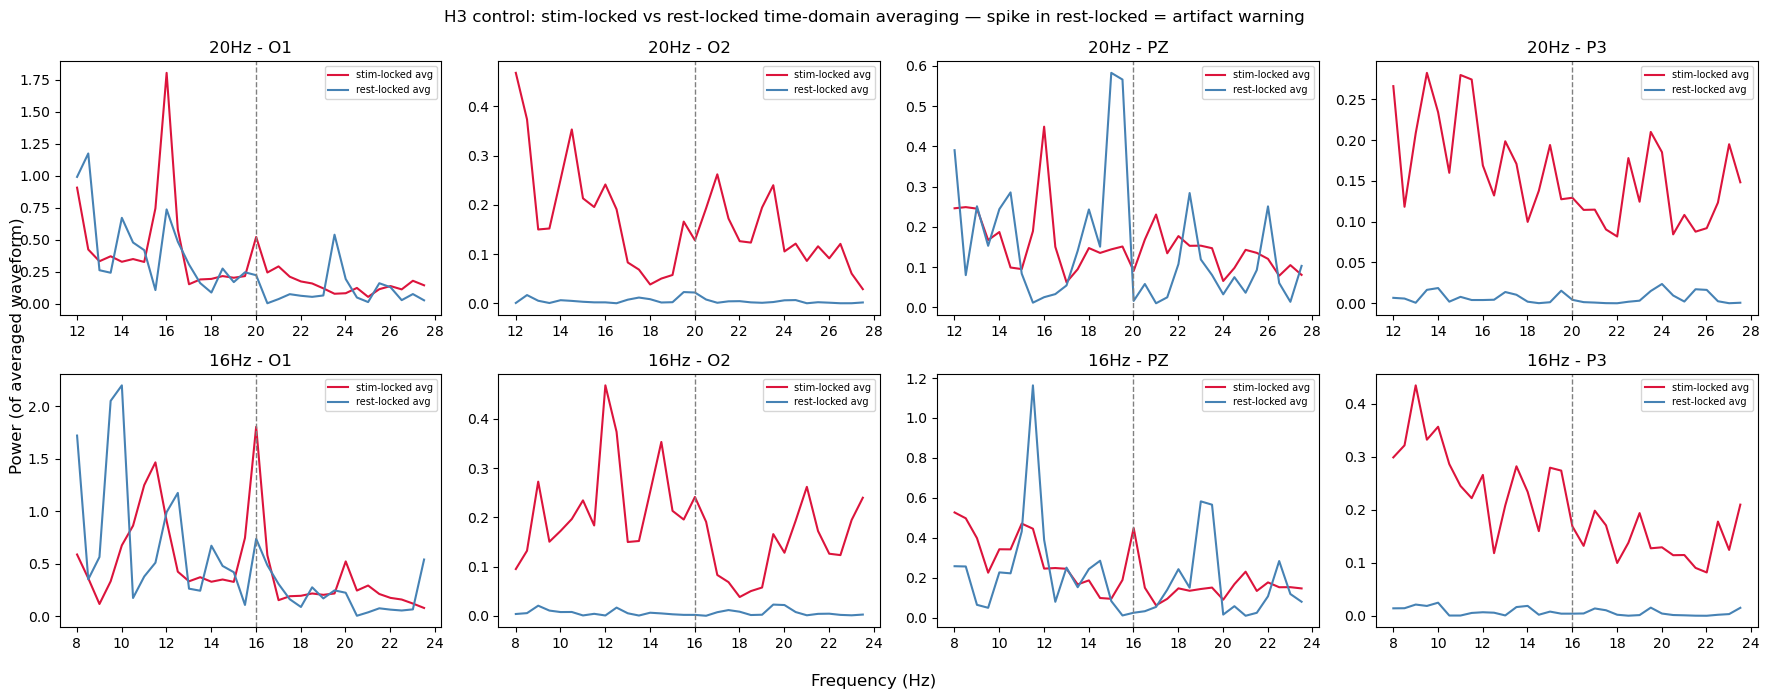

Session Channel Stim-locked peak   Rest-locked peak   Ratio (stim/rest)
20Hz   CZ     0.057              0.025              2.25
20Hz   PZ     0.151              0.566              0.27
20Hz   P4     2.601              0.394              6.60
20Hz   T6     0.904              0.259              3.49
20Hz   T5     0.576              0.147              3.93
20Hz   P3     0.129              0.015              8.40
20Hz   O2     0.166              0.023              7.25
20Hz   O1     0.523              0.247              2.12
16Hz   CZ     0.110              0.055              1.99
16Hz   PZ     0.449              0.025              17.78
16Hz   P4     11.075             0.515              21.52
16Hz   T6     3.681              0.720              5.11
16Hz   T5     0.673              0.057              11.90
16Hz   P3     0.274              0.004              68.57
16Hz   O2     0.241              0.002              119.53
16Hz   O1     1.806              0.738              2.45


In [13]:
def trial_locked_average_spectrum(windows, fs, common_len=None):
    """
    Crops all windows to a common length, averages them in the TIME DOMAIN
    (not power domain), then returns the spectrum of that averaged waveform.
    This is the real phase-lock test: random-phase noise cancels under
    time-domain averaging, genuine phase-locked signal survives and sharpens.
    """
    if common_len is None:
        common_len = min(w.shape[0] for w in windows)
    epochs = np.stack([w[:common_len, :] for w in windows])   # (n_trials, common_len, n_channels)
    avg_waveform = epochs.mean(axis=0)                         # (common_len, n_channels)
    return avg_waveform

def spectrum_of_average(avg_waveform, fs, channel_idx):
    f, P = welch(avg_waveform[:, channel_idx], fs=fs, nperseg=min(int(fs*2), avg_waveform.shape[0]))
    return f, P

# --- Run for both sessions: compare STIM-locked vs REST-locked averaged spectra ---
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

check_channels = ['O1', 'O2', 'PZ', 'P3']

for row, session_name in enumerate(session_names):
    s = sessions[session_name]
    fs = s['fs']
    target_freq = s['target_freq']

    stim_avg = trial_locked_average_spectrum(s['stim_windows'], fs)
    rest_avg = trial_locked_average_spectrum(s['rest_windows'], fs)

    for col, ch_label in enumerate(check_channels):
        ch_idx = eeg_labels.index(ch_label)
        f_stim, P_stim = spectrum_of_average(stim_avg, fs, ch_idx)
        f_rest, P_rest = spectrum_of_average(rest_avg, fs, ch_idx)

        mask_stim = (f_stim >= target_freq - 8) & (f_stim <= target_freq + 8)
        mask_rest = (f_rest >= target_freq - 8) & (f_rest <= target_freq + 8)

        ax = axes[row, col]
        ax.plot(f_stim[mask_stim], P_stim[mask_stim], color='crimson', label='stim-locked avg')
        ax.plot(f_rest[mask_rest], P_rest[mask_rest], color='steelblue', label='rest-locked avg')
        ax.axvline(target_freq, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f'{session_name} - {ch_label}')
        ax.legend(fontsize=7)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Power (of averaged waveform)')
fig.suptitle('H3 control: stim-locked vs rest-locked time-domain averaging — spike in rest-locked = artifact warning')
plt.tight_layout()
plt.show()

# --- Numeric summary: peak height at target freq, stim-locked vs rest-locked, all 8 channels ---
print(f"{'Session':<6} {'Channel':<6} {'Stim-locked peak':<18} {'Rest-locked peak':<18} {'Ratio (stim/rest)'}")
for session_name in session_names:
    s = sessions[session_name]
    fs = s['fs']
    target_freq = s['target_freq']
    stim_avg = trial_locked_average_spectrum(s['stim_windows'], fs)
    rest_avg = trial_locked_average_spectrum(s['rest_windows'], fs)
    for ch_label in eeg_labels:
        ch_idx = eeg_labels.index(ch_label)
        f_s, P_s = spectrum_of_average(stim_avg, fs, ch_idx)
        f_r, P_r = spectrum_of_average(rest_avg, fs, ch_idx)
        peak_s = P_s[(f_s >= target_freq-0.5)&(f_s <= target_freq+0.5)].max()
        peak_r = P_r[(f_r >= target_freq-0.5)&(f_r <= target_freq+0.5)].max()
        ratio = peak_s / peak_r if peak_r > 0 else np.nan
        print(f"{session_name:<6} {ch_label:<6} {peak_s:<18.3f} {peak_r:<18.3f} {ratio:.2f}")

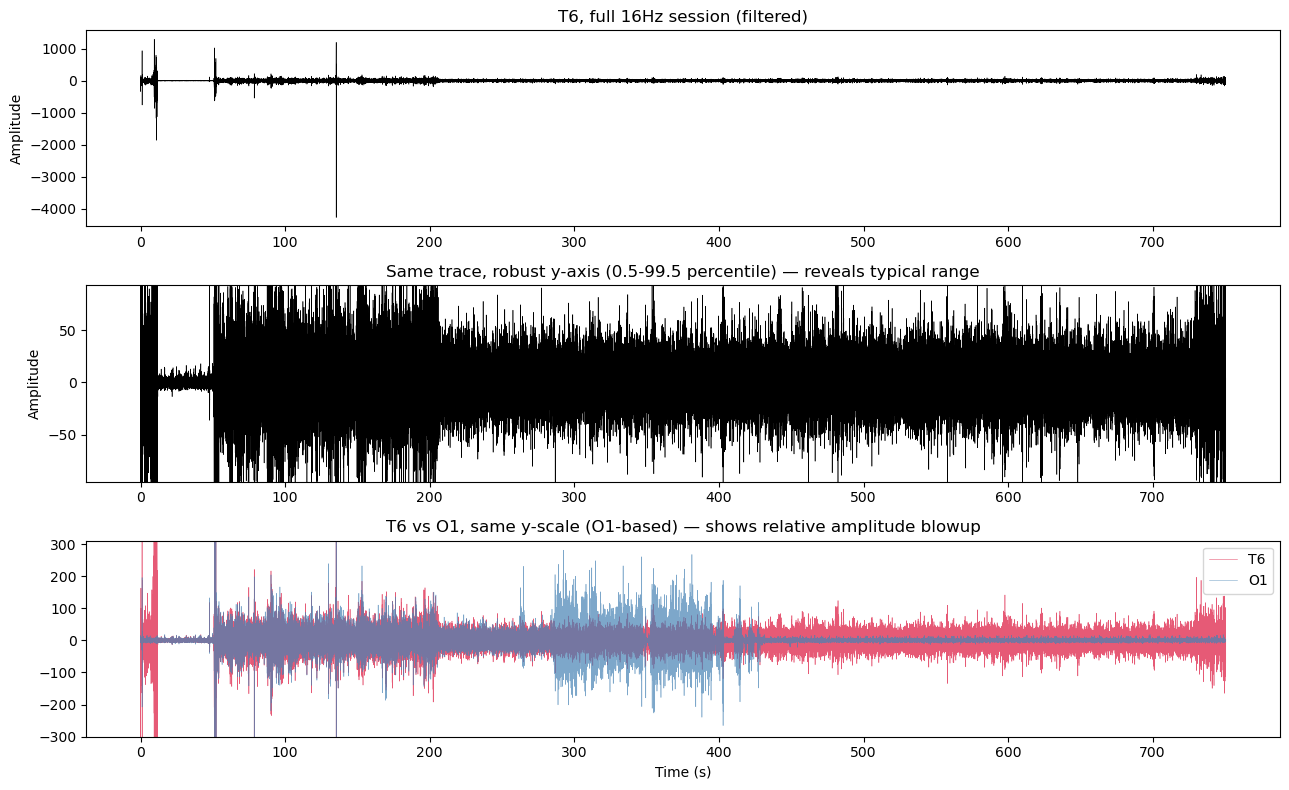

Per-channel amplitude stats, 16Hz session (filtered data):
Channel Std          Max abs      99.9th pctile  
CZ     25.47        4096.67      191.96         
PZ     34.62        4685.25      302.36         
P4     32.17        3659.04      200.86         
T6     40.20        4273.61      445.30         
T5     32.46        4453.97      275.24         
P3     34.42        4132.63      432.51         
O2     43.32        4236.86      575.75         
O1     34.76        4444.73      234.23         


In [14]:
# --- Raw trace check: T6, 16Hz session, full session + zoomed views ---
s16 = sessions['16Hz']
fs16 = s16['fs']
t6_idx = eeg_labels.index('T6')

t6_full = s16['filtered'][:, t6_idx]
t6_time = np.arange(len(t6_full)) / fs16

fig, axes = plt.subplots(3, 1, figsize=(13, 8))

# Full session overview
axes[0].plot(t6_time, t6_full, color='black', linewidth=0.4)
axes[0].set_title('T6, full 16Hz session (filtered)')
axes[0].set_ylabel('Amplitude')

# Robust-scale overview (in case of a few extreme outliers dominating the y-axis)
axes[1].plot(t6_time, t6_full, color='black', linewidth=0.4)
axes[1].set_ylim(np.nanpercentile(t6_full, 0.5), np.nanpercentile(t6_full, 99.5))
axes[1].set_title('Same trace, robust y-axis (0.5-99.5 percentile) — reveals typical range')
axes[1].set_ylabel('Amplitude')

# Compare to O1 on the same robust scale, for reference
o1_idx = eeg_labels.index('O1')
o1_full = s16['filtered'][:, o1_idx]
axes[2].plot(t6_time, t6_full, color='crimson', linewidth=0.4, label='T6', alpha=0.7)
axes[2].plot(t6_time, o1_full, color='steelblue', linewidth=0.4, label='O1', alpha=0.7)
axes[2].set_ylim(np.nanpercentile(o1_full, 0.5)*3, np.nanpercentile(o1_full, 99.5)*3)
axes[2].set_title('T6 vs O1, same y-scale (O1-based) — shows relative amplitude blowup')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Numeric summary: how extreme is T6 vs other channels? ---
print("Per-channel amplitude stats, 16Hz session (filtered data):")
print(f"{'Channel':<6} {'Std':<12} {'Max abs':<12} {'99.9th pctile':<15}")
for ch_label in eeg_labels:
    idx = eeg_labels.index(ch_label)
    trace = s16['filtered'][:, idx]
    print(f"{ch_label:<6} {trace.std():<12.2f} {np.abs(trace).max():<12.2f} {np.percentile(np.abs(trace), 99.9):<15.2f}")

In [15]:
# --- Add a corrected "all_clean" channel set that excludes T6 due to contact degradation ---
CHANNEL_SETS_FULL['all_clean'] = [l for l in eeg_labels if l != 'T6']
print("Clean channel set:", CHANNEL_SETS_FULL['all_clean'])

# --- Rerun PSDA and CCA on all_8 vs all_clean, matched frequency, across all window lengths, both sessions ---
comparison_rows = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in window_lengths:
        for cs_name in ['all_8', 'all_clean']:
            r_psda = run_psda_config_full(session_name, window_sec, cs_name, n_harmonics=1, test_freq=test_freq)
            if r_psda:
                r_psda['method'] = 'PSDA'
                comparison_rows.append(r_psda)
            r_cca = run_cca_config(session_name, window_sec, cs_name, n_harmonics=1, test_freq=test_freq)
            if r_cca:
                comparison_rows.append(r_cca)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[['method','session','window_sec','channel_set','cohens_d','pval','accuracy']].sort_values(
    ['method','session','window_sec']
)

Clean channel set: ['CZ', 'PZ', 'P4', 'T5', 'P3', 'O2', 'O1']


,method,session,window_sec,channel_set,cohens_d,pval,accuracy
17,CCA,16Hz,0.5,all_8,0.387366,1.353983e-21,0.580247
19,CCA,16Hz,0.5,all_clean,0.370885,5.697439e-20,0.592593
21,CCA,16Hz,1.0,all_8,0.626901,6.242150e-34,0.617284
23,CCA,16Hz,1.0,all_clean,0.583733,2.899414e-30,0.567901
25,CCA,16Hz,1.5,all_8,0.714411,7.665429e-28,0.580247
27,CCA,16Hz,1.5,all_clean,0.662357,2.615906e-23,0.592593
29,CCA,16Hz,2.0,all_8,0.875518,1.707114e-21,0.629630
31,CCA,16Hz,2.0,all_clean,0.832622,1.756382e-18,0.617284
1,CCA,20Hz,0.5,all_8,0.207375,1.004951e-07,0.617284
3,CCA,20Hz,0.5,all_clean,0.216555,5.762116e-08,0.617284


In [16]:
def compute_trial_scores(session_name, window_sec, channel_set_name, n_harmonics, test_freq,
                          score_fn, hop_sec=0.1):
    """
    Returns per-trial lists of window-scores (not pooled), for both stim and rest trials.
    score_fn: multichannel_psda_score or multichannel_cca_score
    """
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    def score_trial(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start, end = w * hop_len, w * hop_len + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(score_fn(X, fs, test_freq, n_harmonics))
        return [x for x in scores if not np.isnan(x)]

    stim_trial_scores = [score_trial(t) for t in s['stim_windows']]
    rest_trial_scores = [score_trial(t) for t in s['rest_windows']]
    # keep only trials that produced at least one valid window
    stim_trial_scores = [t for t in stim_trial_scores if len(t) > 0]
    rest_trial_scores = [t for t in rest_trial_scores if len(t) > 0]
    return stim_trial_scores, rest_trial_scores


def leave_one_trial_out_accuracy(stim_trial_scores, rest_trial_scores):
    """
    For each trial (stim or rest), hold it out, compute the threshold from
    ALL OTHER trials' pooled scores (midpoint of medians), then classify the
    held-out trial by majority vote of its own windows against that threshold.
    Returns overall accuracy, plus separate stim-recall and rest-recall.
    """
    all_trials = [('stim', t) for t in stim_trial_scores] + [('rest', t) for t in rest_trial_scores]
    correct = 0
    stim_correct, rest_correct = 0, 0
    n_stim, n_rest = len(stim_trial_scores), len(rest_trial_scores)

    for i, (true_label, held_out) in enumerate(all_trials):
        train_stim = [t for j, (lbl, t) in enumerate(all_trials) if lbl == 'stim' and j != i]
        train_rest = [t for j, (lbl, t) in enumerate(all_trials) if lbl == 'rest' and j != i]

        pooled_stim = np.concatenate(train_stim) if train_stim else np.array([])
        pooled_rest = np.concatenate(train_rest) if train_rest else np.array([])
        if len(pooled_stim) == 0 or len(pooled_rest) == 0:
            continue

        threshold = (np.median(pooled_stim) + np.median(pooled_rest)) / 2
        pred_label = 'stim' if np.mean(np.array(held_out) > threshold) > 0.5 else 'rest'

        if pred_label == true_label:
            correct += 1
            if true_label == 'stim': stim_correct += 1
            else: rest_correct += 1

    n_total = n_stim + n_rest
    return {
        'loto_accuracy': correct / n_total if n_total > 0 else np.nan,
        'loto_stim_recall': stim_correct / n_stim if n_stim > 0 else np.nan,
        'loto_rest_recall': rest_correct / n_rest if n_rest > 0 else np.nan,
        'n_trials': n_total,
    }

# --- Run held-out validation: CCA vs PSDA, all_clean channels, across window lengths, both sessions ---
loto_results = []
for method_name, score_fn in [('PSDA', multichannel_psda_score), ('CCA', multichannel_cca_score)]:
    for session_name in session_names:
        test_freq = sessions[session_name]['target_freq']
        for window_sec in window_lengths:
            stim_scores, rest_scores = compute_trial_scores(
                session_name, window_sec, 'all_clean', n_harmonics=1,
                test_freq=test_freq, score_fn=score_fn)
            loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
            loto['method'] = method_name
            loto['session'] = session_name
            loto['window_sec'] = window_sec
            loto_results.append(loto)

loto_df = pd.DataFrame(loto_results)
loto_df = loto_df[['method','session','window_sec','loto_accuracy','loto_stim_recall','loto_rest_recall','n_trials']]
loto_df.sort_values(['method','session','window_sec'])

,method,session,window_sec,loto_accuracy,loto_stim_recall,loto_rest_recall,n_trials
18,CCA,16Hz,0.5,0.617284,0.547619,0.692308,81
19,CCA,16Hz,1.0,0.617284,0.523810,0.717949,81
20,CCA,16Hz,1.5,0.592593,0.500000,0.692308,81
21,CCA,16Hz,2.0,0.629630,0.500000,0.769231,81
22,CCA,16Hz,3.0,0.000000,0.000000,NaN,42
23,CCA,16Hz,4.0,0.000000,0.000000,NaN,42
12,CCA,20Hz,0.5,0.629630,0.595238,0.666667,81
13,CCA,20Hz,1.0,0.592593,0.523810,0.666667,81
14,CCA,20Hz,1.5,0.530864,0.523810,0.538462,81
15,CCA,20Hz,2.0,0.604938,0.619048,0.589744,81


In [17]:
def build_offset_stim_windows(session_name, offset_sec):
    """
    Rebuilds stim windows starting `offset_sec` AFTER marker-20, instead of
    exactly at it. Uses "next marker-30 after this marker-20" pairing (robust
    to stray/extra markers), matching the logic in load_session.
    """
    s = sessions[session_name]
    fs = s['fs']
    offset_samples = int(offset_sec * fs)
    filtered = s['filtered']

    # Re-derive raw onsets_30 fresh (s['onsets_30'] may include strays not filtered out)
    # We pair robustly: for each corrected onset_20, find the next onset_30 after it.
    onsets_20 = s['onsets_20']   # already corrected/valid in load_session
    onsets_30_all = s['onsets_30']

    offset_windows = []
    for start_20 in onsets_20:
        later_30 = onsets_30_all[onsets_30_all > start_20]
        if len(later_30) == 0:
            continue
        end = later_30[0]
        start = start_20 + offset_samples
        if end > start:
            offset_windows.append(filtered[start:end, :])
    return offset_windows

In [18]:
# --- Test CCA at a frequency neither session ever stimulated at ---
null_freq = 13   # chosen: away from alpha peak (8-13Hz), away from both 16/20Hz targets and their harmonics

null_results = []
for session_name in session_names:
    s = sessions[session_name]
    fs = s['fs']
    real_freq = s['target_freq']

    for freq_label, freq in [('real_target', real_freq), ('null_13Hz', null_freq)]:
        for window_sec in [1.0, 2.0]:
            stim_scores, rest_scores = compute_trial_scores(
                session_name, window_sec, 'all_clean', n_harmonics=1,
                test_freq=freq, score_fn=multichannel_cca_score)
            loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
            loto['session'] = session_name
            loto['freq_tested'] = freq_label
            loto['window_sec'] = window_sec
            null_results.append(loto)

null_df = pd.DataFrame(null_results)
null_df = null_df[['session','freq_tested','window_sec','loto_accuracy','loto_stim_recall','loto_rest_recall']]
print(null_df.to_string(index=False))

session freq_tested  window_sec  loto_accuracy  loto_stim_recall  loto_rest_recall
   20Hz real_target         1.0       0.592593          0.523810          0.666667
   20Hz real_target         2.0       0.604938          0.619048          0.589744
   20Hz   null_13Hz         1.0       0.185185          0.047619          0.333333
   20Hz   null_13Hz         2.0       0.209877          0.095238          0.333333
   16Hz real_target         1.0       0.617284          0.523810          0.717949
   16Hz real_target         2.0       0.629630          0.500000          0.769231
   16Hz   null_13Hz         1.0       0.185185          0.047619          0.333333
   16Hz   null_13Hz         2.0       0.209877          0.095238          0.333333


session freq_tested  window_sec  loto_accuracy  loto_stim_recall  loto_rest_recall
   20Hz real_target         1.0       0.592593          0.523810          0.666667
   20Hz real_target         2.0       0.604938          0.619048          0.589744
   20Hz   null_13Hz         1.0       0.185185          0.047619          0.333333
   20Hz   null_13Hz         2.0       0.209877          0.095238          0.333333
   20Hz   null_27Hz         1.0       0.629630          0.642857          0.615385
   20Hz   null_27Hz         2.0       0.629630          0.619048          0.641026
   16Hz real_target         1.0       0.617284          0.523810          0.717949
   16Hz real_target         2.0       0.629630          0.500000          0.769231
   16Hz   null_13Hz         1.0       0.185185          0.047619          0.333333
   16Hz   null_13Hz         2.0       0.209877          0.095238          0.333333
   16Hz   null_27Hz         1.0       0.629630          0.642857          0.615385
   1

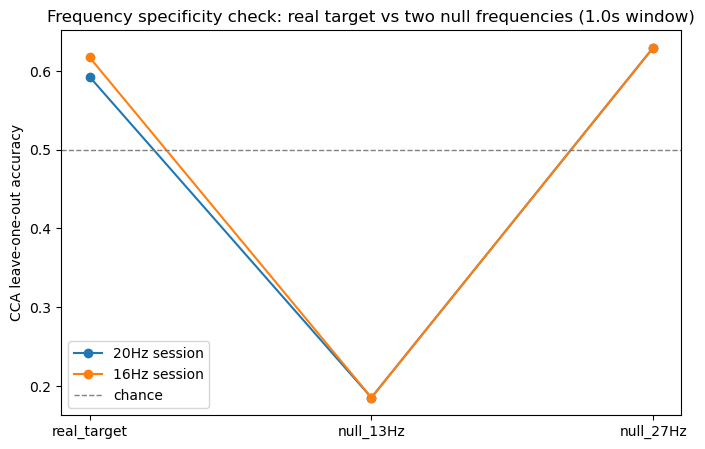

In [19]:
# --- Second null frequency: 27Hz, well clear of alpha (8-13Hz), clear of 16/20Hz targets,
#     and clear of their harmonics (32Hz, 40Hz) -- a cleaner "nothing should be here" test ---
null_freq_2 = 27

null_results_2 = []
for session_name in session_names:
    s = sessions[session_name]
    fs = s['fs']
    real_freq = s['target_freq']

    for freq_label, freq in [('real_target', real_freq), ('null_13Hz', 13), ('null_27Hz', null_freq_2)]:
        for window_sec in [1.0, 2.0]:
            stim_scores, rest_scores = compute_trial_scores(
                session_name, window_sec, 'all_clean', n_harmonics=1,
                test_freq=freq, score_fn=multichannel_cca_score)
            loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
            loto['session'] = session_name
            loto['freq_tested'] = freq_label
            loto['window_sec'] = window_sec
            null_results_2.append(loto)

null_df_2 = pd.DataFrame(null_results_2)
null_df_2 = null_df_2[['session','freq_tested','window_sec','loto_accuracy','loto_stim_recall','loto_rest_recall']]
print(null_df_2.to_string(index=False))

# --- Visual summary: accuracy by frequency tested, both sessions ---
plt.figure(figsize=(8, 5))
freq_order = ['real_target', 'null_13Hz', 'null_27Hz']
for session_name in session_names:
    sub = null_df_2[null_df_2['session'] == session_name]
    sub = sub[sub['window_sec'] == 1.0].set_index('freq_tested').loc[freq_order]
    plt.plot(freq_order, sub['loto_accuracy'], marker='o', label=f'{session_name} session')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
plt.ylabel('CCA leave-one-out accuracy')
plt.title('Frequency specificity check: real target vs two null frequencies (1.0s window)')
plt.legend()
plt.show()

In [20]:
def normalize(x, lower_pct=2, upper_pct=98):
    """
    Robust normalization: clips to the 2nd-98th percentile range before scaling,
    so a few extreme outlier windows don't compress the entire rest of the signal
    down near zero. Values outside the percentile range get clipped to 0 or 1.
    """
    x = np.nan_to_num(x, nan=np.nanmin(x))
    lo, hi = np.percentile(x, [lower_pct, upper_pct])
    x_clipped = np.clip(x, lo, hi)
    return (x_clipped - lo) / (hi - lo + 1e-9)


def compare_psda_vs_cca(session_name, window_sec, channel_set_name, n_harmonics=1, hop_sec=0.1,
                         video_duration_sec=None, playback_speed=20, fps=15, smoothing_sec=1.0,
                         out_name='psda_vs_cca.mp4'):
    """
    Runs BOTH PSDA and CCA scoring on the identical sliding windows (same session,
    same channels, same window/hop), and renders them together for direct comparison.
    """
    s = sessions[session_name]
    fs = s['fs']
    test_freq = s['target_freq']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    filtered = s['filtered']

    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs
    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    psda_scores, cca_scores, timestamps = [], [], []
    for w in range(n_windows):
        start, end = w * hop_len, w * hop_len + window_len
        X = filtered[start:end, ch_idx]
        psda_scores.append(multichannel_psda_score(X, fs, test_freq, n_harmonics))
        cca_scores.append(multichannel_cca_score(X, fs, test_freq, n_harmonics))
        timestamps.append((start + end) / 2 / fs)

    psda_scores = np.array(psda_scores)
    cca_scores = np.array(cca_scores)
    timestamps = np.array(timestamps)

    psda_norm = normalize(psda_scores)
    cca_norm = normalize(cca_scores)

    smooth_n = max(1, int(smoothing_sec / hop_sec))
    psda_smooth = pd.Series(psda_norm).rolling(smooth_n, min_periods=1).mean().values
    cca_smooth = pd.Series(cca_norm).rolling(smooth_n, min_periods=1).mean().values

    psda_metrics = run_psda_config_full(session_name, window_sec, channel_set_name, n_harmonics, test_freq)
    cca_metrics = run_cca_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    for ax in (ax1, ax2):
        ax.set_xlim(0, video_duration_sec)
        for i in range(s['n_trials']):
            t_start, t_end = s['onsets_20'][i]/fs, s['onsets_30'][i]/fs
            ax.axvspan(t_start, t_end, color='gray', alpha=0.15)

    ax1.set_ylim(0, 1.1)
    ax1.set_title(f'PSDA (robust-normalized) — Cohen\'s d={psda_metrics["cohens_d"]:.3f}, '
                   f'acc={psda_metrics["accuracy"]*100:.1f}%')
    line_psda_raw, = ax1.plot([], [], color='steelblue', linewidth=0.4, alpha=0.3)
    line_psda_smooth, = ax1.plot([], [], color='steelblue', linewidth=1.8, label='PSDA')
    ax1.legend(loc='upper right', fontsize=8)

    ax2.set_ylim(0, 1.1)
    ax2.set_title(f'CCA (robust-normalized) — Cohen\'s d={cca_metrics["cohens_d"]:.3f}, '
                   f'acc={cca_metrics["accuracy"]*100:.1f}%')
    ax2.set_xlabel('Time (s)')
    line_cca_raw, = ax2.plot([], [], color='crimson', linewidth=0.4, alpha=0.3)
    line_cca_smooth, = ax2.plot([], [], color='crimson', linewidth=1.8, label='CCA')
    ax2.legend(loc='upper right', fontsize=8)

    fig.suptitle(f'{session_name} session — {channel_set_name} channels, {window_sec}s window — '
                 f'PSDA vs CCA on the IDENTICAL signal')

    playhead1 = ax1.axvline(0, color='black', linewidth=1)
    playhead2 = ax2.axvline(0, color='black', linewidth=1)

    plt.tight_layout()

    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        mask = timestamps <= current_t
        line_psda_raw.set_data(timestamps[mask], psda_norm[mask])
        line_psda_smooth.set_data(timestamps[mask], psda_smooth[mask])
        line_cca_raw.set_data(timestamps[mask], cca_norm[mask])
        line_cca_smooth.set_data(timestamps[mask], cca_smooth[mask])
        playhead1.set_xdata([current_t, current_t])
        playhead2.set_xdata([current_t, current_t])
        return line_psda_raw, line_psda_smooth, line_cca_raw, line_cca_smooth, playhead1, playhead2

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return psda_metrics, cca_metrics


# --- Run on our strongest, best-understood config ---
psda_m, cca_m = compare_psda_vs_cca('20Hz', window_sec=1.0, channel_set_name='all_clean',
                                      out_name='psda_vs_cca_20hz_v2.mp4')
print("PSDA:", psda_m)
print("CCA:", cca_m)
Video('psda_vs_cca_20hz_v2.mp4', embed=True, width=850)

PSDA: {'session': '20Hz', 'actual_freq': 20, 'test_freq': 20, 'window_sec': 1.0, 'channel_set': 'all_clean', 'n_harmonics': 1, 'mean_stim': np.float64(2.5633781110900813), 'mean_rest': np.float64(2.2332697236118455), 'cohens_d': np.float64(0.09432169987640711), 'pval': np.float64(7.822349209605284e-06), 'accuracy': np.float64(0.49382716049382713)}
CCA: {'method': 'CCA', 'session': '20Hz', 'actual_freq': 20, 'test_freq': 20, 'window_sec': 1.0, 'channel_set': 'all_clean', 'n_harmonics': 1, 'n_channels_used': 7, 'mean_stim': np.float64(0.36507751016783996), 'mean_rest': np.float64(0.33928112474104966), 'cohens_d': np.float64(0.36193474899017125), 'pval': np.float64(2.8711374356051537e-13), 'accuracy': np.float64(0.5802469135802469)}


In [21]:
def make_subband_filter(band_low, band_high, fs, order=4):
    nyq = fs / 2
    band_high = min(band_high, nyq - 1)  # guard against exceeding Nyquist
    return butter(order, [band_low/nyq, band_high/nyq], btype='band')

def fbcca_score(X, fs, target_freq, n_harmonics=3, band_width=4.0):
    """
    Filter Bank CCA (Chen et al., 2015):
      - For each harmonic h (1..n_harmonics), bandpass X around h*target_freq
        (a band of width `band_width` Hz centered there), then compute a plain
        CCA correlation between that sub-band signal and a reference containing
        ALL harmonics up to n_harmonics (standard FBCCA practice: sub-band filtered
        EEG vs full multi-harmonic reference).
      - Combine the per-band correlations with the standard Chen et al. weighting:
        w_h = h^-1.25 + 0.25
      - Final score = sum(w_h * rho_h^2), taking the sign from the correlations.
    """
    n_samples, n_channels = X.shape
    refs = make_reference(target_freq, n_samples, fs, n_harmonics=n_harmonics)

    weighted_sum = 0.0
    for h in range(1, n_harmonics + 1):
        f_center = target_freq * h
        band_low = max(f_center - band_width/2, 1.0)
        band_high = f_center + band_width/2
        try:
            b_sub, a_sub = make_subband_filter(band_low, band_high, fs)
            X_sub = filtfilt(b_sub, a_sub, X, axis=0)
        except ValueError:
            continue  # band exceeds valid range (e.g. harmonic too close to Nyquist) -> skip

        rho = cca_score(X_sub, refs)
        w_h = h ** (-1.25) + 0.25   # Chen et al. 2015 harmonic weighting
        weighted_sum += w_h * (rho ** 2)

    return weighted_sum

def multichannel_fbcca_score(X, fs, target_freq, n_harmonics=3):
    """Matches the (X, fs, target_freq, n_harmonics) signature used by run_*_config functions."""
    return fbcca_score(X, fs, target_freq, n_harmonics=n_harmonics)

# --- Sanity check on the same config we tested PSDA and CCA on first ---
test_session = sessions['20Hz']
test_window = test_session['stim_windows'][0][:int(test_session['fs']*2), :]
ch_idx = get_channel_indices_full('all_clean')
test_score = multichannel_fbcca_score(test_window[:, ch_idx], test_session['fs'], target_freq=20, n_harmonics=3)
print(f"Sanity check - all_clean FBCCA score, trial 0, 2s window, 20Hz target, 3 harmonics: {test_score:.4f}")

Sanity check - all_clean FBCCA score, trial 0, 2s window, 20Hz target, 3 harmonics: 1.7790


In [22]:
# --- Redefine make_bandpass with a wider default ceiling (was 45Hz, now 65Hz) ---
# 65Hz covers the 3rd harmonic of both 16Hz (48Hz) and 20Hz (60Hz) targets with margin.
def make_bandpass(low=4, high=65, fs=251.7, order=4):
    nyq = fs / 2
    return butter(order, [low/nyq, high/nyq], btype='band')

# --- Reload both sessions with the widened filter (everything else in load_session unchanged) ---
sessions = {
    '20Hz': load_session(
        path_raw,
        path_health,
        target_freq=20),
    '16Hz': load_session(
        path_raw,
        path_health,
        target_freq=16),
}

for name, s in sessions.items():
    stim_lens = [w.shape[0] for w in s['stim_windows']]
    print(f"{name}: fs={s['fs']:.2f}, trials={s['n_trials']}, "
          f"stim_lens=[{min(stim_lens)}-{max(stim_lens)}], rest_windows={len(s['rest_windows'])}")

# --- Re-run the FBCCA sanity check on the newly-widened data ---
test_session = sessions['20Hz']
test_window = test_session['stim_windows'][0][:int(test_session['fs']*2), :]
ch_idx = get_channel_indices_full('all_clean')
test_score = multichannel_fbcca_score(test_window[:, ch_idx], test_session['fs'], target_freq=20, n_harmonics=3)
print(f"\nSanity check (widened filter) - all_clean FBCCA score, trial 0, 2s window, 20Hz, 3 harmonics: {test_score:.4f}")

20Hz: fs=249.70, trials=42, stim_lens=[2491-3271], rest_windows=39
16Hz: fs=249.70, trials=42, stim_lens=[2491-3271], rest_windows=39

Sanity check (widened filter) - all_clean FBCCA score, trial 0, 2s window, 20Hz, 3 harmonics: 1.8288


In [23]:
def run_fbcca_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    """Same structure as run_cca_config, scored via FBCCA instead."""
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)

    def score_trial_windows(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start, end = w * hop_len, w * hop_len + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(multichannel_fbcca_score(X, fs, test_freq, n_harmonics))
        return scores

    all_stim, all_rest = [], []
    per_trial_stim, per_trial_rest = [], []
    for trial in s['stim_windows']:
        sc = score_trial_windows(trial); per_trial_stim.append(sc); all_stim.extend(sc)
    for trial in s['rest_windows']:
        sc = score_trial_windows(trial); per_trial_rest.append(sc); all_rest.extend(sc)

    all_stim = np.array([x for x in all_stim if not np.isnan(x)])
    all_rest = np.array([x for x in all_rest if not np.isnan(x)])
    if len(all_stim) < 2 or len(all_rest) < 2:
        return None

    mean_stim, mean_rest = all_stim.mean(), all_rest.mean()
    pooled_std = np.sqrt((all_stim.std()**2 + all_rest.std()**2) / 2)
    cohens_d = (mean_stim - mean_rest) / pooled_std if pooled_std > 0 else np.nan
    try:
        _, pval = mannwhitneyu(all_stim, all_rest, alternative='greater')
    except ValueError:
        pval = np.nan

    return {'method': 'FBCCA', 'session': session_name, 'window_sec': window_sec,
            'channel_set': channel_set_name, 'n_harmonics': n_harmonics,
            'mean_stim': mean_stim, 'mean_rest': mean_rest, 'cohens_d': cohens_d, 'pval': pval}

# --- 1. Effect-size sweep across window lengths, all_clean channels, both sessions ---
fbcca_results = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in window_lengths:
        r = run_fbcca_config(session_name, window_sec, 'all_clean', n_harmonics=3, test_freq=test_freq)
        if r: fbcca_results.append(r)

fbcca_df = pd.DataFrame(fbcca_results)
print("=== FBCCA effect size across window lengths ===")
print(fbcca_df[['session','window_sec','cohens_d','pval']].to_string(index=False))

# --- 2. LOTO cross-validated accuracy, same as we did for CCA ---
fbcca_loto_results = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in [1.0, 2.0]:
        stim_scores, rest_scores = compute_trial_scores(
            session_name, window_sec, 'all_clean', n_harmonics=3,
            test_freq=test_freq, score_fn=multichannel_fbcca_score)
        loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
        loto['session'] = session_name
        loto['window_sec'] = window_sec
        fbcca_loto_results.append(loto)

fbcca_loto_df = pd.DataFrame(fbcca_loto_results)
print("\n=== FBCCA leave-one-trial-out accuracy ===")
print(fbcca_loto_df[['session','window_sec','loto_accuracy','loto_stim_recall','loto_rest_recall']].to_string(index=False))

# --- 3. Null-frequency control (13Hz, 27Hz), same protocol as CCA ---
fbcca_null_results = []
for session_name in session_names:
    s = sessions[session_name]
    real_freq = s['target_freq']
    for freq_label, freq in [('real_target', real_freq), ('null_13Hz', 13), ('null_27Hz', 27)]:
        stim_scores, rest_scores = compute_trial_scores(
            session_name, 1.0, 'all_clean', n_harmonics=3,
            test_freq=freq, score_fn=multichannel_fbcca_score)
        loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
        loto['session'] = session_name
        loto['freq_tested'] = freq_label
        fbcca_null_results.append(loto)

fbcca_null_df = pd.DataFrame(fbcca_null_results)
print("\n=== FBCCA null-frequency control (1.0s window) ===")
print(fbcca_null_df[['session','freq_tested','loto_accuracy','loto_stim_recall','loto_rest_recall']].to_string(index=False))

=== FBCCA effect size across window lengths ===
session  window_sec  cohens_d         pval
   20Hz         0.5  0.052109 1.115014e-01
   20Hz         1.0  0.049836 1.656532e-01
   20Hz         1.5  0.181692 6.442282e-05
   20Hz         2.0  0.302561 2.066141e-05
   16Hz         0.5  0.061608 6.023603e-02
   16Hz         1.0  0.202451 4.817371e-06
   16Hz         1.5  0.411364 1.989715e-15
   16Hz         2.0  0.589104 3.496741e-15

=== FBCCA leave-one-trial-out accuracy ===
session  window_sec  loto_accuracy  loto_stim_recall  loto_rest_recall
   20Hz         1.0       0.567901          0.500000          0.641026
   20Hz         2.0       0.567901          0.571429          0.564103
   16Hz         1.0       0.654321          0.714286          0.589744
   16Hz         2.0       0.629630          0.619048          0.641026

=== FBCCA null-frequency control (1.0s window) ===
session freq_tested  loto_accuracy  loto_stim_recall  loto_rest_recall
   20Hz real_target       0.567901         

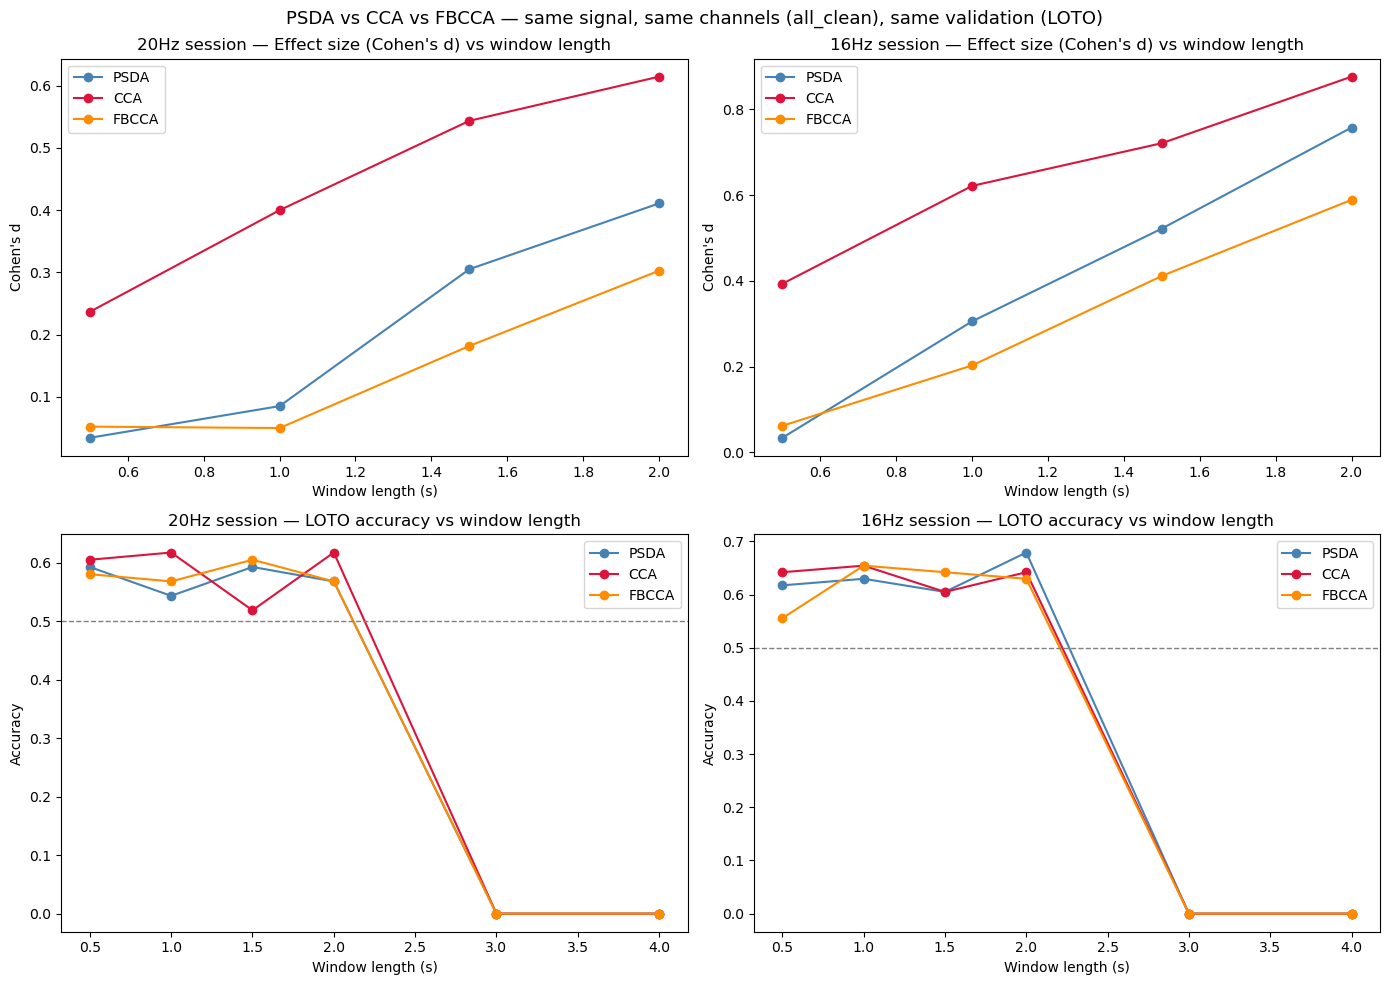

=== Best window length per method (by Cohen's d) ===
PSDA   20Hz  best window=2.0s, d=0.411
PSDA   16Hz  best window=2.0s, d=0.758
CCA    20Hz  best window=2.0s, d=0.614
CCA    16Hz  best window=2.0s, d=0.877
FBCCA  20Hz  best window=2.0s, d=0.303
FBCCA  16Hz  best window=2.0s, d=0.589


In [24]:
# --- Consolidate results from all three methods into one comparison table ---
# Recompute PSDA effect-size sweep on all_clean (matching what CCA/FBCCA used) for fair comparison
psda_compare_results = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in window_lengths:
        r = run_psda_config_full(session_name, window_sec, 'all_clean', n_harmonics=1, test_freq=test_freq)
        if r:
            r['method'] = 'PSDA'
            psda_compare_results.append(r)
psda_compare_df = pd.DataFrame(psda_compare_results)

cca_compare_results = []
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    for window_sec in window_lengths:
        r = run_cca_config(session_name, window_sec, 'all_clean', n_harmonics=1, test_freq=test_freq)
        if r:
            cca_compare_results.append(r)
cca_compare_df = pd.DataFrame(cca_compare_results)

# fbcca_df already computed in Cell 23 (all_clean, 3 harmonics, both sessions, all window lengths)

# --- LOTO accuracy for all three methods, same window lengths, for the accuracy panel ---
def get_loto_series(score_fn, n_harmonics, session_name, windows_to_test=[0.5,1.0,1.5,2.0,3.0,4.0]):
    accs = []
    test_freq = sessions[session_name]['target_freq']
    for w in windows_to_test:
        stim_scores, rest_scores = compute_trial_scores(
            session_name, w, 'all_clean', n_harmonics, test_freq, score_fn)
        loto = leave_one_trial_out_accuracy(stim_scores, rest_scores)
        accs.append(loto['loto_accuracy'])
    return accs

loto_by_method = {}
for method_name, score_fn, nh in [('PSDA', multichannel_psda_score, 1),
                                    ('CCA', multichannel_cca_score, 1),
                                    ('FBCCA', multichannel_fbcca_score, 3)]:
    for session_name in session_names:
        loto_by_method[(method_name, session_name)] = get_loto_series(score_fn, nh, session_name)

# --- Build the clean 2x2 comparison figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'PSDA': 'steelblue', 'CCA': 'crimson', 'FBCCA': 'darkorange'}

# Panel 1: Cohen's d vs window length, 20Hz session
ax = axes[0, 0]
for method_name, df in [('PSDA', psda_compare_df), ('CCA', cca_compare_df), ('FBCCA', fbcca_df)]:
    sub = df[df['session'] == '20Hz'].sort_values('window_sec')
    ax.plot(sub['window_sec'], sub['cohens_d'], marker='o', color=colors[method_name], label=method_name)
ax.set_title("20Hz session — Effect size (Cohen's d) vs window length")
ax.set_xlabel('Window length (s)'); ax.set_ylabel("Cohen's d")
ax.legend()

# Panel 2: Cohen's d vs window length, 16Hz session
ax = axes[0, 1]
for method_name, df in [('PSDA', psda_compare_df), ('CCA', cca_compare_df), ('FBCCA', fbcca_df)]:
    sub = df[df['session'] == '16Hz'].sort_values('window_sec')
    ax.plot(sub['window_sec'], sub['cohens_d'], marker='o', color=colors[method_name], label=method_name)
ax.set_title("16Hz session — Effect size (Cohen's d) vs window length")
ax.set_xlabel('Window length (s)'); ax.set_ylabel("Cohen's d")
ax.legend()

# Panel 3: LOTO accuracy vs window length, 20Hz
ax = axes[1, 0]
windows_to_test = [0.5,1.0,1.5,2.0,3.0,4.0]
for method_name in ['PSDA', 'CCA', 'FBCCA']:
    ax.plot(windows_to_test, loto_by_method[(method_name, '20Hz')], marker='o', color=colors[method_name], label=method_name)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_title('20Hz session — LOTO accuracy vs window length')
ax.set_xlabel('Window length (s)'); ax.set_ylabel('Accuracy')
ax.legend()

# Panel 4: LOTO accuracy vs window length, 16Hz
ax = axes[1, 1]
for method_name in ['PSDA', 'CCA', 'FBCCA']:
    ax.plot(windows_to_test, loto_by_method[(method_name, '16Hz')], marker='o', color=colors[method_name], label=method_name)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_title('16Hz session — LOTO accuracy vs window length')
ax.set_xlabel('Window length (s)'); ax.set_ylabel('Accuracy')
ax.legend()

fig.suptitle('PSDA vs CCA vs FBCCA — same signal, same channels (all_clean), same validation (LOTO)', fontsize=13)
plt.tight_layout()
plt.show()

# --- Summary table: best config per method per session ---
print("=== Best window length per method (by Cohen's d) ===")
for method_name, df in [('PSDA', psda_compare_df), ('CCA', cca_compare_df), ('FBCCA', fbcca_df)]:
    for session_name in session_names:
        sub = df[df['session'] == session_name]
        best = sub.loc[sub['cohens_d'].idxmax()]
        print(f"{method_name:<6} {session_name:<5} best window={best['window_sec']}s, d={best['cohens_d']:.3f}")

In [25]:
def compare_three_methods(session_name, window_sec, channel_set_name='all_clean', hop_sec=0.1,
                           video_duration_sec=None, playback_speed=20, fps=15, smoothing_sec=1.0,
                           out_name='three_method_compare.mp4'):
    """
    Runs PSDA, CCA, and FBCCA on the IDENTICAL sliding windows (same session,
    channels, window/hop), and renders all three stacked for direct comparison.
    """
    s = sessions[session_name]
    fs = s['fs']
    test_freq = s['target_freq']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    filtered = s['filtered']

    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs
    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    psda_scores, cca_scores, fbcca_scores, timestamps = [], [], [], []
    for w in range(n_windows):
        start, end = w * hop_len, w * hop_len + window_len
        X = filtered[start:end, ch_idx]
        psda_scores.append(multichannel_psda_score(X, fs, test_freq, n_harmonics=1))
        cca_scores.append(multichannel_cca_score(X, fs, test_freq, n_harmonics=1))
        fbcca_scores.append(multichannel_fbcca_score(X, fs, test_freq, n_harmonics=3))
        timestamps.append((start + end) / 2 / fs)

    psda_scores = np.array(psda_scores)
    cca_scores = np.array(cca_scores)
    fbcca_scores = np.array(fbcca_scores)
    timestamps = np.array(timestamps)

    psda_norm = normalize(psda_scores)
    cca_norm = normalize(cca_scores)
    fbcca_norm = normalize(fbcca_scores)

    smooth_n = max(1, int(smoothing_sec / hop_sec))
    psda_smooth = pd.Series(psda_norm).rolling(smooth_n, min_periods=1).mean().values
    cca_smooth = pd.Series(cca_norm).rolling(smooth_n, min_periods=1).mean().values
    fbcca_smooth = pd.Series(fbcca_norm).rolling(smooth_n, min_periods=1).mean().values

    psda_metrics = run_psda_config_full(session_name, window_sec, channel_set_name, 1, test_freq)
    cca_metrics = run_cca_config(session_name, window_sec, channel_set_name, 1, test_freq)
    fbcca_metrics = run_fbcca_config(session_name, window_sec, channel_set_name, 3, test_freq)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    panels = [
        (ax1, 'PSDA', 'steelblue', psda_norm, psda_smooth, psda_metrics),
        (ax2, 'CCA', 'crimson', cca_norm, cca_smooth, cca_metrics),
        (ax3, 'FBCCA', 'darkorange', fbcca_norm, fbcca_smooth, fbcca_metrics),
    ]

    lines_raw, lines_smooth, playheads = [], [], []
    for ax, name, color, norm_scores, smooth_scores, metrics in panels:
        ax.set_xlim(0, video_duration_sec)
        ax.set_ylim(0, 1.1)
        d_str = f"{metrics['cohens_d']:.2f}" if metrics else "n/a"
        ax.set_title(f"{name} — Cohen's d={d_str}")
        for i in range(s['n_trials']):
            t_start, t_end = s['onsets_20'][i]/fs, s['onsets_30'][i]/fs
            ax.axvspan(t_start, t_end, color='gray', alpha=0.15)
        lr, = ax.plot([], [], color=color, linewidth=0.4, alpha=0.3)
        ls, = ax.plot([], [], color=color, linewidth=1.8, label=name)
        ph = ax.axvline(0, color='black', linewidth=1)
        ax.legend(loc='upper right', fontsize=8)
        lines_raw.append(lr); lines_smooth.append(ls); playheads.append(ph)

    ax3.set_xlabel('Time (s)')
    fig.suptitle(f'{session_name} session — PSDA vs CCA vs FBCCA on the IDENTICAL signal '
                 f'({window_sec}s window, {channel_set_name})')
    plt.tight_layout()

    all_norm = [psda_norm, cca_norm, fbcca_norm]
    all_smooth = [psda_smooth, cca_smooth, fbcca_smooth]

    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        mask = timestamps <= current_t
        artists = []
        for i in range(3):
            lines_raw[i].set_data(timestamps[mask], all_norm[i][mask])
            lines_smooth[i].set_data(timestamps[mask], all_smooth[i][mask])
            playheads[i].set_xdata([current_t, current_t])
            artists += [lines_raw[i], lines_smooth[i], playheads[i]]
        return artists

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return psda_metrics, cca_metrics, fbcca_metrics


# --- Run the three-method comparison across both sessions and both window lengths ---
configs_to_render = [
    ('20Hz', 1.0, 'three_method_20hz_1s.mp4'),
    ('20Hz', 2.0, 'three_method_20hz_2s.mp4'),
    ('16Hz', 1.0, 'three_method_16hz_1s.mp4'),
    ('16Hz', 2.0, 'three_method_16hz_2s.mp4'),
]

all_metrics = {}
for session_name, window_sec, out_name in configs_to_render:
    print(f"Rendering {session_name}, {window_sec}s window -> {out_name} ...")
    psda_m, cca_m, fbcca_m = compare_three_methods(session_name, window_sec=window_sec, out_name=out_name)
    all_metrics[(session_name, window_sec)] = {'PSDA': psda_m, 'CCA': cca_m, 'FBCCA': fbcca_m}
    print(f"  PSDA d={psda_m['cohens_d']:.3f} | CCA d={cca_m['cohens_d']:.3f} | FBCCA d={fbcca_m['cohens_d']:.3f}")

print("\nAll four videos rendered.")

Rendering 20Hz, 1.0s window -> three_method_20hz_1s.mp4 ...
  PSDA d=0.085 | CCA d=0.400 | FBCCA d=0.050
Rendering 20Hz, 2.0s window -> three_method_20hz_2s.mp4 ...
  PSDA d=0.411 | CCA d=0.614 | FBCCA d=0.303
Rendering 16Hz, 1.0s window -> three_method_16hz_1s.mp4 ...
  PSDA d=0.305 | CCA d=0.622 | FBCCA d=0.202
Rendering 16Hz, 2.0s window -> three_method_16hz_2s.mp4 ...
  PSDA d=0.758 | CCA d=0.877 | FBCCA d=0.589

All four videos rendered.


In [26]:
# ============================================================
# PART A: Hardware-friendly CCA definitions (from Cell 27)
# ============================================================

def precompute_reference_terms(freq, n_samples, fs, n_harmonics=1):
    """Precomputes everything that depends only on (freq, window length, fs) -- not on EEG data."""
    Y = make_reference(freq, n_samples, fs, n_harmonics)
    Y = Y - Y.mean(axis=0, keepdims=True)
    Cyy = Y.T @ Y
    Cyy_inv = np.linalg.inv(Cyy + 1e-8 * np.eye(Cyy.shape[0]))
    return Y, Cyy_inv

def hw_friendly_cca_score(X, Y, Cyy_inv, n_power_iters=8):
    """Hardware-friendly CCA via small covariance matrices + power iteration (no QR/SVD on full window)."""
    X = X - X.mean(axis=0, keepdims=True)
    Cxx = X.T @ X
    Cxy = X.T @ Y
    Cxx_inv = np.linalg.inv(Cxx + 1e-6 * np.eye(Cxx.shape[0]))
    M = Cxx_inv @ Cxy @ Cyy_inv @ Cxy.T

    v = np.ones(M.shape[0]) / np.sqrt(M.shape[0])
    for _ in range(n_power_iters):
        v = M @ v
        norm = np.linalg.norm(v)
        if norm < 1e-12:
            return 0.0
        v = v / norm
    eigenvalue = v @ M @ v
    return np.sqrt(max(eigenvalue, 0.0))

def multichannel_hwcca_score(X, fs, target_freq, n_harmonics=1, precomputed=None):
    if precomputed is None:
        Y, Cyy_inv = precompute_reference_terms(target_freq, X.shape[0], fs, n_harmonics)
    else:
        Y, Cyy_inv = precomputed
    return hw_friendly_cca_score(X, Y, Cyy_inv)


# ============================================================
# PART B: Sweep + LOTO helper functions for HW-CCA
# ============================================================

def run_hwcca_config(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    Y_pre, Cyy_inv_pre = precompute_reference_terms(test_freq, window_len, fs, n_harmonics)

    def score_trial_windows(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start, end = w * hop_len, w * hop_len + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(multichannel_hwcca_score(X, fs, test_freq, n_harmonics, precomputed=(Y_pre, Cyy_inv_pre)))
        return scores

    all_stim, all_rest = [], []
    for trial in s['stim_windows']:
        all_stim.extend(score_trial_windows(trial))
    for trial in s['rest_windows']:
        all_rest.extend(score_trial_windows(trial))

    all_stim = np.array([x for x in all_stim if not np.isnan(x)])
    all_rest = np.array([x for x in all_rest if not np.isnan(x)])
    if len(all_stim) < 2 or len(all_rest) < 2:
        return None

    mean_stim, mean_rest = all_stim.mean(), all_rest.mean()
    pooled_std = np.sqrt((all_stim.std()**2 + all_rest.std()**2) / 2)
    cohens_d = (mean_stim - mean_rest) / pooled_std if pooled_std > 0 else np.nan
    _, pval = mannwhitneyu(all_stim, all_rest, alternative='greater')
    return {'method': 'HW-CCA', 'session': session_name, 'window_sec': window_sec,
            'cohens_d': cohens_d, 'pval': pval}

def compute_trial_scores_hwcca(session_name, window_sec, channel_set_name, n_harmonics, test_freq, hop_sec=0.1):
    s = sessions[session_name]
    fs = s['fs']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    Y_pre, Cyy_inv_pre = precompute_reference_terms(test_freq, window_len, fs, n_harmonics)

    def score_trial(trial_data):
        scores = []
        n_w = (trial_data.shape[0] - window_len) // hop_len
        for w in range(max(n_w, 0)):
            start, end = w * hop_len, w * hop_len + window_len
            X = trial_data[start:end, ch_idx]
            scores.append(multichannel_hwcca_score(X, fs, test_freq, n_harmonics, precomputed=(Y_pre, Cyy_inv_pre)))
        return [x for x in scores if not np.isnan(x)]

    stim_scores = [score_trial(t) for t in s['stim_windows']]
    rest_scores = [score_trial(t) for t in s['rest_windows']]
    stim_scores = [t for t in stim_scores if len(t) > 0]
    rest_scores = [t for t in rest_scores if len(t) > 0]
    return stim_scores, rest_scores


# ============================================================
# PART C: Run full validation, 1.0s window
# ============================================================

window_sec = 1.0

print("=== Effect size, 1.0s window ===")
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    r_orig = run_cca_config(session_name, window_sec, 'all_clean', 1, test_freq)
    r_hw = run_hwcca_config(session_name, window_sec, 'all_clean', 1, test_freq)
    print(f"{session_name}: CCA d={r_orig['cohens_d']:.3f} (p={r_orig['pval']:.2e})  |  "
          f"HW-CCA d={r_hw['cohens_d']:.3f} (p={r_hw['pval']:.2e})")

print("\n=== LOTO cross-validated accuracy, 1.0s window ===")
for session_name in session_names:
    test_freq = sessions[session_name]['target_freq']
    stim_o, rest_o = compute_trial_scores(session_name, window_sec, 'all_clean', 1, test_freq, multichannel_cca_score)
    loto_orig = leave_one_trial_out_accuracy(stim_o, rest_o)
    stim_hw, rest_hw = compute_trial_scores_hwcca(session_name, window_sec, 'all_clean', 1, test_freq)
    loto_hw = leave_one_trial_out_accuracy(stim_hw, rest_hw)
    print(f"{session_name}: CCA acc={loto_orig['loto_accuracy']*100:.1f}%  |  HW-CCA acc={loto_hw['loto_accuracy']*100:.1f}%")

print("\n=== Null-frequency control, 1.0s window ===")
for session_name in session_names:
    s = sessions[session_name]
    real_freq = s['target_freq']
    for freq_label, freq in [('real_target', real_freq), ('null_13Hz', 13), ('null_27Hz', 27)]:
        stim_o, rest_o = compute_trial_scores(session_name, window_sec, 'all_clean', 1, freq, multichannel_cca_score)
        loto_o = leave_one_trial_out_accuracy(stim_o, rest_o)
        stim_hw, rest_hw = compute_trial_scores_hwcca(session_name, window_sec, 'all_clean', 1, freq)
        loto_hw = leave_one_trial_out_accuracy(stim_hw, rest_hw)
        print(f"{session_name} {freq_label:<12}: CCA acc={loto_o['loto_accuracy']*100:5.1f}%  |  HW-CCA acc={loto_hw['loto_accuracy']*100:5.1f}%")

print("\n=== Compute time per window, 1.0s window ===")
test_session = sessions['20Hz']
window_len_bench = int(test_session['fs'] * window_sec)
test_window = test_session['stim_windows'][0][:window_len_bench, :]
ch_idx = get_channel_indices_full('all_clean')
X_test = test_window[:, ch_idx]

n_bench = 300
t0 = time.perf_counter()
for _ in range(n_bench):
    multichannel_cca_score(X_test, test_session['fs'], target_freq=20, n_harmonics=1)
orig_time = (time.perf_counter() - t0) / n_bench * 1000

Y_pre, Cyy_inv_pre = precompute_reference_terms(20, X_test.shape[0], test_session['fs'], n_harmonics=1)
t0 = time.perf_counter()
for _ in range(n_bench):
    multichannel_hwcca_score(X_test, test_session['fs'], target_freq=20, n_harmonics=1, precomputed=(Y_pre, Cyy_inv_pre))
hw_time = (time.perf_counter() - t0) / n_bench * 1000

print(f"Original CCA: {orig_time:.4f} ms/window")
print(f"HW-friendly CCA: {hw_time:.4f} ms/window")
print(f"Speedup: {orig_time/hw_time:.2f}x")


# ============================================================
# PART D: Video comparison, CCA vs HW-CCA, same signal
# ============================================================

def compare_cca_vs_hwcca(session_name, window_sec, channel_set_name='all_clean', hop_sec=0.1,
                          video_duration_sec=None, playback_speed=20, fps=15, smoothing_sec=1.0,
                          out_name='cca_vs_hwcca.mp4'):
    s = sessions[session_name]
    fs = s['fs']
    test_freq = s['target_freq']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    filtered = s['filtered']

    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs
    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    Y_pre, Cyy_inv_pre = precompute_reference_terms(test_freq, window_len, fs, n_harmonics=1)

    cca_scores, hwcca_scores, timestamps = [], [], []
    for w in range(n_windows):
        start, end = w * hop_len, w * hop_len + window_len
        X = filtered[start:end, ch_idx]
        cca_scores.append(multichannel_cca_score(X, fs, test_freq, n_harmonics=1))
        hwcca_scores.append(multichannel_hwcca_score(X, fs, test_freq, n_harmonics=1, precomputed=(Y_pre, Cyy_inv_pre)))
        timestamps.append((start + end) / 2 / fs)

    cca_scores, hwcca_scores, timestamps = np.array(cca_scores), np.array(hwcca_scores), np.array(timestamps)
    cca_norm, hwcca_norm = normalize(cca_scores), normalize(hwcca_scores)

    smooth_n = max(1, int(smoothing_sec / hop_sec))
    cca_smooth = pd.Series(cca_norm).rolling(smooth_n, min_periods=1).mean().values
    hwcca_smooth = pd.Series(hwcca_norm).rolling(smooth_n, min_periods=1).mean().values

    cca_metrics = run_cca_config(session_name, window_sec, channel_set_name, 1, test_freq)
    hwcca_metrics = run_hwcca_config(session_name, window_sec, channel_set_name, 1, test_freq)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    panels = [(ax1, 'CCA (original)', 'crimson', cca_norm, cca_smooth, cca_metrics),
              (ax2, 'HW-CCA (ESP32-friendly)', 'seagreen', hwcca_norm, hwcca_smooth, hwcca_metrics)]

    lines_raw, lines_smooth, playheads = [], [], []
    for ax, name, color, norm_s, smooth_s, metrics in panels:
        ax.set_xlim(0, video_duration_sec)
        ax.set_ylim(0, 1.1)
        d_str = f"{metrics['cohens_d']:.2f}" if metrics else "n/a"
        ax.set_title(f"{name} — Cohen's d={d_str}")
        for i in range(s['n_trials']):
            t_start, t_end = s['onsets_20'][i]/fs, s['onsets_30'][i]/fs
            ax.axvspan(t_start, t_end, color='gray', alpha=0.15)
        lr, = ax.plot([], [], color=color, linewidth=0.4, alpha=0.3)
        ls, = ax.plot([], [], color=color, linewidth=1.8, label=name)
        ph = ax.axvline(0, color='black', linewidth=1)
        ax.legend(loc='upper right', fontsize=8)
        lines_raw.append(lr); lines_smooth.append(ls); playheads.append(ph)

    ax2.set_xlabel('Time (s)')
    fig.suptitle(f'{session_name} session — CCA vs Hardware-Friendly CCA ({window_sec}s window)')
    plt.tight_layout()

    all_norm = [cca_norm, hwcca_norm]
    all_smooth = [cca_smooth, hwcca_smooth]
    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        mask = timestamps <= current_t
        artists = []
        for i in range(2):
            lines_raw[i].set_data(timestamps[mask], all_norm[i][mask])
            lines_smooth[i].set_data(timestamps[mask], all_smooth[i][mask])
            playheads[i].set_xdata([current_t, current_t])
            artists += [lines_raw[i], lines_smooth[i], playheads[i]]
        return artists

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return cca_metrics, hwcca_metrics

cca_m, hwcca_m = compare_cca_vs_hwcca('20Hz', window_sec=1.0, out_name='cca_vs_hwcca_20hz.mp4')
print("\nCCA:", cca_m)
print("HW-CCA:", hwcca_m)
Video('cca_vs_hwcca_20hz.mp4', embed=True, width=850)

=== Effect size, 1.0s window ===
20Hz: CCA d=0.400 (p=9.58e-16)  |  HW-CCA d=0.398 (p=1.16e-15)
16Hz: CCA d=0.622 (p=2.60e-33)  |  HW-CCA d=0.621 (p=4.38e-33)

=== LOTO cross-validated accuracy, 1.0s window ===
20Hz: CCA acc=61.7%  |  HW-CCA acc=61.7%
16Hz: CCA acc=65.4%  |  HW-CCA acc=64.2%

=== Null-frequency control, 1.0s window ===
20Hz real_target : CCA acc= 61.7%  |  HW-CCA acc= 61.7%
20Hz null_13Hz   : CCA acc= 17.3%  |  HW-CCA acc= 18.5%
20Hz null_27Hz   : CCA acc= 60.5%  |  HW-CCA acc= 60.5%
16Hz real_target : CCA acc= 65.4%  |  HW-CCA acc= 64.2%
16Hz null_13Hz   : CCA acc= 17.3%  |  HW-CCA acc= 18.5%
16Hz null_27Hz   : CCA acc= 60.5%  |  HW-CCA acc= 60.5%

=== Compute time per window, 1.0s window ===
Original CCA: 0.0869 ms/window
HW-friendly CCA: 0.0445 ms/window
Speedup: 1.95x

CCA: {'method': 'CCA', 'session': '20Hz', 'actual_freq': 20, 'test_freq': 20, 'window_sec': 1.0, 'channel_set': 'all_clean', 'n_harmonics': 1, 'n_channels_used': 7, 'mean_stim': np.float64(0.33157894

In [27]:
cca_m_16, hwcca_m_16 = compare_cca_vs_hwcca('16Hz', window_sec=1.0, out_name='cca_vs_hwcca_16hz.mp4')
print("CCA (16Hz):", cca_m_16)
print("HW-CCA (16Hz):", hwcca_m_16)
Video('cca_vs_hwcca_16hz.mp4', embed=True, width=850)

CCA (16Hz): {'method': 'CCA', 'session': '16Hz', 'actual_freq': 16, 'test_freq': 16, 'window_sec': 1.0, 'channel_set': 'all_clean', 'n_harmonics': 1, 'n_channels_used': 7, 'mean_stim': np.float64(0.3866936210228067), 'mean_rest': np.float64(0.3354485471355897), 'cohens_d': np.float64(0.6216406499728389), 'pval': np.float64(2.5974952854802894e-33), 'accuracy': np.float64(0.6296296296296297)}
HW-CCA (16Hz): {'method': 'HW-CCA', 'session': '16Hz', 'window_sec': 1.0, 'cohens_d': np.float64(0.6209341970435547), 'pval': np.float64(4.377876105132906e-33)}


In [28]:
def compare_cca_vs_hwcca_freq(session_name, window_sec, test_freq, channel_set_name='all_clean', hop_sec=0.1,
                               video_duration_sec=None, playback_speed=20, fps=15, smoothing_sec=1.0,
                               out_name='cca_vs_hwcca_freq.mp4'):
    """
    Same as compare_cca_vs_hwcca, but test_freq is now an explicit parameter --
    letting us score against a frequency OTHER than the session's real stimulation
    frequency (e.g. 17Hz, which neither the 20Hz nor 16Hz session ever presented).
    """
    s = sessions[session_name]
    fs = s['fs']
    real_freq = s['target_freq']
    ch_idx = get_channel_indices_full(channel_set_name)
    window_len = int(fs * window_sec)
    hop_len = int(fs * hop_sec)
    filtered = s['filtered']

    if video_duration_sec is None:
        video_duration_sec = filtered.shape[0] / fs
    end_sample = min(int(video_duration_sec * fs), filtered.shape[0])
    n_windows = (end_sample - window_len) // hop_len

    Y_pre, Cyy_inv_pre = precompute_reference_terms(test_freq, window_len, fs, n_harmonics=1)

    cca_scores, hwcca_scores, timestamps = [], [], []
    for w in range(n_windows):
        start, end = w * hop_len, w * hop_len + window_len
        X = filtered[start:end, ch_idx]
        cca_scores.append(multichannel_cca_score(X, fs, test_freq, n_harmonics=1))
        hwcca_scores.append(multichannel_hwcca_score(X, fs, test_freq, n_harmonics=1, precomputed=(Y_pre, Cyy_inv_pre)))
        timestamps.append((start + end) / 2 / fs)

    cca_scores, hwcca_scores, timestamps = np.array(cca_scores), np.array(hwcca_scores), np.array(timestamps)
    cca_norm, hwcca_norm = normalize(cca_scores), normalize(hwcca_scores)

    smooth_n = max(1, int(smoothing_sec / hop_sec))
    cca_smooth = pd.Series(cca_norm).rolling(smooth_n, min_periods=1).mean().values
    hwcca_smooth = pd.Series(hwcca_norm).rolling(smooth_n, min_periods=1).mean().values

    # --- Metrics computed by hand here since test_freq != session's real target_freq ---
    def get_metrics(score_fn, precomputed=None):
        stim_scores, rest_scores = [], []
        for trial in s['stim_windows']:
            n_w = (trial.shape[0] - window_len) // hop_len
            for w in range(max(n_w, 0)):
                st, en = w*hop_len, w*hop_len+window_len
                X = trial[st:en, ch_idx]
                stim_scores.append(score_fn(X, fs, test_freq, 1) if precomputed is None
                                    else score_fn(X, fs, test_freq, 1, precomputed=precomputed))
        for trial in s['rest_windows']:
            n_w = (trial.shape[0] - window_len) // hop_len
            for w in range(max(n_w, 0)):
                st, en = w*hop_len, w*hop_len+window_len
                X = trial[st:en, ch_idx]
                rest_scores.append(score_fn(X, fs, test_freq, 1) if precomputed is None
                                    else score_fn(X, fs, test_freq, 1, precomputed=precomputed))
        stim_scores, rest_scores = np.array(stim_scores), np.array(rest_scores)
        pooled_std = np.sqrt((stim_scores.std()**2 + rest_scores.std()**2) / 2)
        d = (stim_scores.mean() - rest_scores.mean()) / pooled_std if pooled_std > 0 else np.nan
        return {'cohens_d': d}

    cca_metrics = get_metrics(multichannel_cca_score)
    hwcca_metrics = get_metrics(multichannel_hwcca_score, precomputed=(Y_pre, Cyy_inv_pre))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    panels = [(ax1, 'CCA (original)', 'crimson', cca_norm, cca_smooth, cca_metrics),
              (ax2, 'HW-CCA (ESP32-friendly)', 'seagreen', hwcca_norm, hwcca_smooth, hwcca_metrics)]

    lines_raw, lines_smooth, playheads = [], [], []
    for ax, name, color, norm_s, smooth_s, metrics in panels:
        ax.set_xlim(0, video_duration_sec)
        ax.set_ylim(0, 1.1)
        ax.set_title(f"{name} — tested @ {test_freq}Hz (real stim = {real_freq}Hz) — Cohen's d={metrics['cohens_d']:.2f}")
        for i in range(s['n_trials']):
            t_start, t_end = s['onsets_20'][i]/fs, s['onsets_30'][i]/fs
            ax.axvspan(t_start, t_end, color='gray', alpha=0.15)
        lr, = ax.plot([], [], color=color, linewidth=0.4, alpha=0.3)
        ls, = ax.plot([], [], color=color, linewidth=1.8, label=name)
        ph = ax.axvline(0, color='black', linewidth=1)
        ax.legend(loc='upper right', fontsize=8)
        lines_raw.append(lr); lines_smooth.append(ls); playheads.append(ph)

    ax2.set_xlabel('Time (s)')
    fig.suptitle(f'{session_name} session — MISMATCHED reference test ({test_freq}Hz vs real {real_freq}Hz stim)')
    plt.tight_layout()

    all_norm = [cca_norm, hwcca_norm]
    all_smooth = [cca_smooth, hwcca_smooth]
    frame_step_sec = playback_speed / fps
    n_frames = int(video_duration_sec / frame_step_sec)

    def update(frame):
        current_t = frame * frame_step_sec
        mask = timestamps <= current_t
        artists = []
        for i in range(2):
            lines_raw[i].set_data(timestamps[mask], all_norm[i][mask])
            lines_smooth[i].set_data(timestamps[mask], all_smooth[i][mask])
            playheads[i].set_xdata([current_t, current_t])
            artists += [lines_raw[i], lines_smooth[i], playheads[i]]
        return artists

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True, interval=1000/fps)
    ani.save(out_name, writer='ffmpeg', fps=fps)
    plt.close(fig)
    return cca_metrics, hwcca_metrics

# --- Run on both sessions, testing against 17Hz (a frequency neither session ever presented) ---
cca_17_20, hwcca_17_20 = compare_cca_vs_hwcca_freq('20Hz', window_sec=1.0, test_freq=17, out_name='mismatch_17hz_on_20hz.mp4')
print("20Hz session tested @17Hz - CCA:", cca_17_20, " | HW-CCA:", hwcca_17_20)

cca_17_16, hwcca_17_16 = compare_cca_vs_hwcca_freq('16Hz', window_sec=1.0, test_freq=17, out_name='mismatch_17hz_on_16hz.mp4')
print("16Hz session tested @17Hz - CCA:", cca_17_16, " | HW-CCA:", hwcca_17_16)

20Hz session tested @17Hz - CCA: {'cohens_d': np.float64(0.04225174631668147)}  | HW-CCA: {'cohens_d': np.float64(0.04438141266136565)}
16Hz session tested @17Hz - CCA: {'cohens_d': np.float64(0.04225174631668147)}  | HW-CCA: {'cohens_d': np.float64(0.04438141266136565)}
